<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=200>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/hospitalization-risk-predictor/blob/main/notebooks/01_eda.ipynb)

# **Análisis de Datos - Taller 1**


--------------------------------------------------------------------

**Análisis exploratorio de datos**

Grupo 4 - MIAA

Fecha: 08/31/2026

________________________________________________________________________

# **Integrantes:**

*   Juan David Martinez Legarda
*   Daniel Velasco López
*   Juan Esteban Cardona Garcia
*   Katherin Adriana Camargo Cetina
*   Kami Matsumi Takegami Benavides

# Análisis Exploratorio de Datos (EDA) — Grupo 4

## Caso: Predicción de Riesgo de Hospitalización en Cohortes de Diabetes e Hipertensión (EPS)

---

Este cuaderno constituye una **guía metodológica completa** que reproduce, paso a paso, el flujo general de trabajo presentado en clase. El objetivo pedagógico es que el estudiante comprenda no solamente *cómo* se ejecuta cada instrucción, sino *por qué* se ejecuta y *qué decisión de negocio* respalda cada una de ellas.

El flujo que seguiremos es el siguiente:

> **Pregunta SMART + Hipótesis → Análisis Inicial → Diccionario de datos → Visión general → Limpieza → Análisis univariado → Análisis bivariado → Conclusiones**

En cada sección se indicará de manera explícita a qué etapa del flujo corresponde, con el fin de mantener la trazabilidad entre la teoría vista en la presentación y su implementación práctica.

*Glosario:* Al final del documento, en el punto 9, encontrarán un glosario de terminos médicos, que incluímos para facilitar el entendimiento de este Notebook.

---
# 1. El problema de negocio y la Pregunta SMART

> *Etapa del flujo: **Pregunta SMART + Hipótesis***

La gestión del riesgo en salud requiere que las EPS en Colombia puedan identificar de manera oportuna los cambios que pueden afectar la evolución clínica y el comportamiento de sus afiliados. En poblaciones con enfermedades crónicas, como diabetes e hipertensión, pequeñas variaciones en la utilización de servicios, los tratamientos o los resultados clínicos pueden convertirse con el tiempo en eventos de mayor complejidad. Sin embargo, anticipar estos cambios representa un desafío cuando se gestionan miles de pacientes y grandes volúmenes de información. Por esta razón, resulta fundamental evolucionar hacia mecanismos que permitan identificar señales tempranas y actuar antes de que una situación se convierta en una urgencia, hospitalización o evento de alto costo.

Actualmente hay una diferencia entre la cantidad de pacientes de las cohortes de diabetes e hipertensión en riesgo de hospitalización y los que realmente terminan hospitalizados. Se busca predecir que pacientes podrían terminar hospitalizados y, mediante controles y medidas preventivas, evitar que terminen en una condición de salud tan deteriorada que requiera hospitalización.

## 1.1. Contexto del negocio

Las EPS en Colombia gestionan grandes poblaciones de afiliados agrupadas en cohortes de riesgo, es decir, grupos de personas que comparten una condición de salud común, como diabetes o hipertensión, que requiere seguimiento permanente. Uno de los principales retos es identificar de manera oportuna a aquellos pacientes cuyo estado de salud comienza a deteriorarse y que, si no son detectados a tiempo, podrían requerir una hospitalización en el mediano plazo.

Hoy, esta identificación suele realizarse mediante reglas estáticas, indicadores retrospectivos o revisión manual por parte de equipos asistenciales y administrativos — mecanismos que normalmente identifican una situación crítica cuando el paciente ya superó un límite previamente definido, no antes.

La dirección de gestión del riesgo plantea la siguiente inquietud:

> *"¿Qué características clínicas, farmacológicas y sociodemográficas de un paciente permiten anticipar si requerirá una hospitalización en el próximo año?"*

Conocer estos factores es estratégico, porque permite priorizar intervenciones preventivas (seguimiento domiciliario, telemonitoreo) sobre los pacientes de mayor riesgo real, en lugar de actuar de forma reactiva una vez ocurre el evento.

*Impacto:*

Para la EPS, esto puede generar un aumento progresivo en la utilización de servicios y en los costos de atención.

- Incrementos inusuales en la frecuencia de consultas o servicios.
- Aumento progresivo de visitas a urgencias.
- Hospitalizaciones repetidas.
- Incremento acelerado del costo de atención.
- Solicitudes frecuentes o inusuales de autorizaciones.
- Cambios inesperados en los tratamientos o medicamentos.
- Deterioro progresivo de indicadores clínicos.
- Abandono de controles y programas de seguimiento.
- Evolución de un paciente estable hacia una condición de mayor complejidad.

*Áreas afectadas:*

- Gestión del riesgo
- Atención primaria/seguimiento
- Cuentas médicas — con impacto clínico (descompensación no anticipada).
- Área operativa (recursos mal priorizados).
- Área financiera (costos evitables de hospitalización).

## 1.2. Formulación de la Pregunta SMART

Una pregunta **SMART** es aquella que resulta **E**specífica, **M**edible, **A**ccionable, **R**ealista y acotada en el **T**iempo. Reformulamos la inquietud del negocio en estos términos:

> **Pregunta SMART:** *"¿Puede un modelo de clasificación binaria, utilizando información histórica de diagnósticos, tratamiento, laboratorio y utilización de servicios, identificar con una precisión mínima del 80% a los pacientes de las cohortes de diabetes e hipertensión que presentarán al menos una hospitalización durante los próximos 12 meses, permitiendo priorizar intervenciones preventivas (seguimiento domiciliario o telemonitoreo) y reducir en al menos 10% la tasa de hospitalizaciones en la población intervenida durante un periodo piloto de 12 meses, frente a un grupo de comparación equivalente?"*

## 1.3. Hipótesis de trabajo

A partir del conocimiento del dominio, planteamos hipótesis exploratorias que el análisis buscará explorar, no confirmar de forma definitiva —dado que el EDA es de carácter exploratorio y no un estudio confirmatorio—:  `

- **H1 (Adherencia al tratamiento):** Existe una asociación entre el nivel de adherencia terapéutica de los pacientes y la ocurrencia de hospitalizaciones durante un año. Se espera observar una asociación entre niveles bajos de adherencia terapéutica (`adherencia_tratamiento_0_100`) y una mayor proporción de pacientes hospitalizados en un año.
- **H2 (Control glucémico y hemodinámico):** Existe una relación entre los niveles de control glucémico y hemodinámico de los pacientes y la ocurrencia de hospitalizaciones durante el periodo de seguimiento. Se espera que los pacientes fuera de las metas terapéuticas de control glucémico (`control_glucemico=0`) o de presión arterial (`control_presion_arterial=0`) presenten una mayor tasa de hospitalización que quienes sí están dentro de las metas.
- **H3 (Comorbilidades y complicaciones previas):** La presencia y cantidad de complicaciones crónicas y comorbilidades se relacionan con la ocurrencia de hospitalizaciones durante los 12 meses posteriores al seguimiento. Se espera que la presencia de comorbilidades crónicas (`comorbilidad_erc`) o de una complicación previa (`complicacion_diabetes_previa`) esté entre los factores más asociados con la probabilidad de hospitalización.
- **H4 (Acceso geográfico):** Las características geográficas de los pacientes presentan una asociación con la ocurrencia de hospitalizaciones durante el periodo de seguimiento. Se espera observar diferencias en la tasa de hospitalización según la zona de residencia (`zona`) y el tiempo de desplazamiento hacia la IPS (`tiempo_desplazamiento_ips_min`), reflejando posibles barreras de acceso a atención ambulatoria oportuna.

El propósito del EDA será determinar si el conjunto de datos disponible **contiene información suficiente y de calidad** para responder la pregunta SMART y explorar estas hipótesis.

## 1.4. Métricas (KPI):

- Precisión de pacientes priorizados de alto riesgo — Precisión = Pacientes priorizados que fueron hospitalizados / Total priorizados. Meta: ≥ 80%, medida sobre el 10-20% de pacientes con mayor probabilidad estimada.

- Tasa de intervención efectiva sobre alertas generadas Definición: Tasa de intervención = Pacientes alertados que recibieron intervención preventiva documentada / Total de pacientes alertados por el modelo × 100

La primera valida el desempeño predictivo del modelo; la segunda valida el impacto real de la intervención, y requiere diseño con grupo de control (el dataset sintético por sí solo no permite demostrar causalidad).

El problema se ilustra con la variable `hospitalizaciones_12m`, usando variables ya disponibles (en el dataset 57 columnas), anclados a datos que la EPS ya recolecta.

----
# 2. Complejidad y disponibilidad de datos:

> *Etapa del flujo: Análisis Inicial*

## 2.1. Qué datos existen o se necesitan, y su fuente probable

El proyecto requiere datos internos de la EPS y datos externos consolidados del Ministerio de Salud de Colombia:


- **Afiliaciones**: Edad, sexo, ubicación, régimen, antigüedad y estado de afiliación
- **RIPS / prestaciones**: Diagnósticos, procedimientos, consultas, hospitalizaciones y urgencias.
- **Autorizaciones**: Solicitudes, servicios, frecuencia, estado y prestador
- **Medicamentos**: Dispensaciones, principio activo, frecuencia y cambios de tratamiento
- **Cuentas médicas**: Valores facturados, reconocidos, glosas y costos por paciente.
- **Gestión del riesgo**: Cohorte, subcohorte, variables clínicas, resultados de laboratorio e indicadores
- **Historia longitudinal**: Eventos de todos los procesos anteriores, ordenados cronológicamente por paciente
- **SISPRO**: (Sistema Integral de Información de la Protección Social) Es una plataforma oficial del Ministerio de Salud y Protección Social de Colombia que centraliza, procesa y consolida los datos del sector de la salud y la protección social
- **CAC**: La Cuenta de Alto Costo (CAC) es un organismo técnico e independiente del Sistema General de Seguridad Social en Salud de Colombia que gestiona, verifica y analiza información sobre las enfermedades de alto costo en el país.

## 2.2. El dataset final utilizado

La disponibilidad real dependerá de la calidad, completitud y oportunidad de integración de estas fuentes; para el modelo real, en este caso, se utilizarán datos de prueba.

Se generó un dataset con datos sintéticos de 1.500.000 registros correspondientes a personas con diabetes e hipertensión. Estos datos fueron generados mediante IA generativa, tomando como referencia las características de datos reales ofuscados y fuentes de información públicas de Colombia (SISPRO, Cuenta de Alto Costo y datos.gov.co).

## 2.3. Complejidad del problema:

- Número de variables: 57 en el diccionario disponible, de las cuales ~50 son potenciales predictoras y 7 son variables objetivo distintas (control glucémico, control de presión arterial, evento cardiovascular, hospitalización, mortalidad, riesgo alto general) Esta multiplicidad de targets implica que no es un solo modelo, sino varios modelos independientes o un enfoque multi-tarea.
- Heterogeneidad de tipos de dato: categóricas nominales (departamento, nivel_educativo), categóricas ordinales (albuminuria_categoria: A1/A2/A3), binarias (usa_insulina, comorbilidad_erc), y numéricas continuas/discretas (hba1c_pct, hospitalizaciones_12m) — cada tipo exige un tratamiento distinto antes del modelado.
- Redundancia/derivación entre variables: se identificaron relaciones de derivación directa (ej. hospitalizacion_relacionada_12m equivalente a hospitalizaciones_12m; categoria_imc derivable de imc) que deben mapearse para evitar usar la misma información como predictor y como variable objetivo simultáneamente.
- Procesos involucrados: al menos seis procesos organizacionales distintos deben integrarse en producción (afiliaciones, RIPS/prestaciones, autorizaciones, farmacia, cuentas médicas, gestión del riesgo), cada uno con su propio sistema de origen, formato y frecuencia de actualización — lo cual implica un esfuerzo considerable de integración (ETL) antes de poder modelar. (Eso sería para la información real, cabe aclarar que estamos trabajando con data de prueba generada por IA).
- Dificultad técnica: más allá del volumen de variables, la naturaleza longitudinal del problema (trayectorias de pacientes en el tiempo, no un corte transversal) exige construir variables a partir de ventanas temporales (ej. "urgencias en los últimos 12 meses") y evitar cuidadosamente fuga de datos temporal usar solo información disponible antes de la fecha de predicción.

## 2.4. Justificación del uso de IA / Ciencia de Datos

### 2.4.1. Predicción del riesgo de hospitalización a 12 meses

Este caso busca identificar de forma anticipada qué pacientes con patologías como diabetes e hipertensión tienen una alta probabilidad de requerir un ingreso hospitalario en el próximo año.

- Tipo de tarea: Clasificación binaria.
- Variable objetivo: hospitalizaciones_12m.

*Técnica propuesta:* clasificación binaria supervisada, usando hospitalizaciones_12m recodificada como variable objetivo binaria (1 = tuvo al menos una hospitalización en 12 meses, 0 = no tuvo ninguna).

El problema no puede resolverse eficazmente con reglas estáticas, porque la relación entre las variables clínicas, sociodemográficas y farmacológicas disponibles y el riesgo real de hospitalización es multivariable y no lineal un umbral fijo sobre una sola variable ignora cómo interactúa con otras (adherencia, función renal, urgencias previas) para determinar el riesgo real de un paciente específico.

### 2.4.2. Por qué es pertinente (no genérica):

- La variable objetivo ya existe en los datos históricos con valores reales de ocurrencia, permitiendo entrenamiento supervisado directo sin necesidad de etiquetado manual.
- El output del modelo (una probabilidad estimada por paciente) permite ordenar y priorizar a la población por riesgo, en vez de solo clasificar en dos grupos rígidos — habilitando directamente el criterio de "priorizar al 10-20% de mayor riesgo" ya establecido en la métrica del proyecto.

Impacto en gestión del riesgo: Permite estratificar la población para incluir a los pacientes de mayor riesgo en programas de seguimiento domiciliario o telemonitoreo, reduciendo admisiones evitables y costos de alta complejidad.

## 2.5. Carga del conjunto de datos

Comenzamos importando las librerías que utilizaremos a lo largo de todo el cuaderno. Se recomienda concentrar las importaciones al inicio para facilitar la lectura y el mantenimiento del código.

- **pandas**: manipulación de datos tabulares.
- **numpy**: operaciones numéricas y manejo del marcador de valores perdidos `NaN`.
- **matplotlib** y **seaborn**: construcción de las visualizaciones que sustentan el análisis.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Configuración estética general de las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

# Evita que pandas trunque columnas al visualizar
pd.set_option("display.max_columns", None)

El conjunto de datos original **no incluye una fila de encabezados**, por lo que debemos proporcionar manualmente la lista de nombres de las columnas. Esta lista constituye, de hecho, el primer insumo para elaborar el **diccionario de datos** de la siguiente sección.

Los nombres han sido traducidos al español y normalizados (minúsculas, sin espacios) para facilitar su manipulación posterior.

In [2]:
# Ruta local al dataset (colocar el CSV junto a este cuaderno)
filename = "dataset_ofuscado_colombia_diabetes_hipertension.csv" #TODO: Actualizar ruta de acuerdo a la ubicación del archivo

df = pd.read_csv(filename)

print("El conjunto de datos se cargó correctamente.")
print(f"Dimensiones: {df.shape[0]} filas (pacientes) y {df.shape[1]} columnas (atributos).")
df.head()

El conjunto de datos se cargó correctamente.
Dimensiones: 1500000 filas (pacientes) y 57 columnas (atributos).


,id_registro,fecha_corte,departamento,zona,sexo,edad_anios,grupo_edad,nivel_socioeconomico,regimen_afiliacion,nivel_educativo,estado_civil,situacion_laboral,personas_hogar,tipo_vivienda,diabetes_tipo,anios_desde_dx_diabetes,anios_desde_dx_hipertension,imc,categoria_imc,perimetro_abdominal_cm,tabaquismo,cigarrillos_dia,alcohol_frecuencia,actividad_fisica_min_sem,calidad_dieta_0_100,horas_sueno,estres_0_10,adherencia_tratamiento_0_100,consultas_atencion_primaria_12m,urgencias_12m,hospitalizaciones_12m,gasto_bolsillo_cop_mensual,distancia_ips_km,tiempo_desplazamiento_ips_min,tension_sistolica_mmhg,tension_diastolica_mmhg,hba1c_pct,glucosa_ayunas_mg_dl,colesterol_ldl_mg_dl,trigliceridos_mg_dl,egfr_ml_min_1_73m2,albuminuria_categoria,medicamento_antidiabetico_principal,usa_insulina,medicamento_antihipertensivo_principal,usa_estatina,comorbilidad_erc,comorbilidad_dislipidemia,comorbilidad_obesidad,complicacion_diabetes_previa,riesgo_cv_10_anios_pct,control_glucemico,control_presion_arterial,evento_cardiovascular_12m,hospitalizacion_relacionada_12m,muerte_12m,riesgo_alto_12m
0,1,2026-08-01,Norte de Santander,Urbana,M,57,45_59,Bajo,Contributivo,Primaria,Casado_union_libre,Ocupado,5,Propia,Tipo_2,6,10,30.8,Obesidad_I,111.8,Nunca,0,Semanal,119,65.7,7.4,5.6,81.9,3,1,0,96604,2.0,20,167,95,6.4,181,176,128,67.9,A1,Metformina,0,Combinacion,0,0,0,1,0,19.8,1,0,0,0,0,1
1,2,2026-08-01,Córdoba,Urbana,F,70,60_74,Medio,Contributivo,Secundaria,Casado_union_libre,No_activo,4,Familiar_otro,Tipo_2,16,23,35.5,Obesidad_II,113.9,Nunca,0,Nunca,38,88.2,7.1,6.4,55.3,2,0,0,101183,9.1,29,179,102,7.4,188,163,270,42.2,A1,Metformina,0,Calcioantagonista,1,1,1,1,0,43.7,0,0,0,0,0,1
2,3,2026-08-01,Cesar,Urbana,F,52,45_59,Bajo,Subsidiado,Secundaria,Casado_union_libre,Ocupado,3,Propia,Tipo_2,25,5,23.8,Normal,102.4,Exfumador,0,Mensual_o_menor,157,75.1,7.0,3.8,53.5,8,0,0,94821,8.0,37,151,104,8.0,212,209,141,60.0,A1,Metformina_DPP4,0,ARA_II,0,1,0,0,1,25.5,0,0,0,0,0,1
3,4,2026-08-01,Magdalena,Urbana,M,55,45_59,Bajo,Subsidiado,Secundaria,Casado_union_libre,Ocupado,4,Propia,Tipo_2,23,13,26.8,Sobrepeso,109.8,Nunca,0,Semanal,127,76.3,7.7,6.0,69.9,7,0,0,142336,22.6,89,177,89,8.3,214,160,308,79.5,A1,Insulina,1,ARA_II,0,0,0,0,1,30.3,0,0,0,0,0,1
4,5,2026-08-01,Antioquia,Urbana,M,86,75_mas,Medio,Contributivo,Primaria,Separado_viudo,No_activo,2,Arriendo,Tipo_2,30,47,25.4,Sobrepeso,104.7,Exfumador,0,Nunca,50,55.8,6.0,4.4,97.7,7,0,0,608265,26.1,94,174,95,8.7,239,95,216,28.3,A3,Insulina,1,Diuretico,1,1,1,0,1,54.2,0,0,0,0,0,1


---
# 3. Diccionario de datos

> *Etapa del flujo: **Diccionario de datos***

El diccionario de datos es el documento que describe el **significado, el tipo y la relevancia esperada** de cada variable. Es una pieza fundamental del EDA porque nos permite interpretar correctamente los datos y detectar de antemano qué variables son candidatas a responder nuestra pregunta de negocio.

Siguiendo la estructura vista en clase, para cada variable documentamos cuatro elementos:

- **Variable:** nombre del atributo.
- **Tipo:** categórico, numérico (continuo/discreto), booleano, etc.
- **Contexto:** información del dominio que ayuda a entender el espacio semántico de la variable. En nuestro caso, el contexto es **clínico-asistencial**, propio de la gestión del riesgo en salud de una EPS.
- **Expectativa:** qué tan relevante creemos que es la variable respecto a nuestra tarea (predecir hospitalización en los próximos 12 meses). Usamos una escala **Alta / Media / Baja**.

## 3.1. Diccionario del conjunto de datos de pacientes (HTA / DBM)

| Variable | Tipo | Contexto | Expectativa |
|---|---|---|---|
| `id_registro` | Numérico (discreto) | Identificador administrativo del registro. | Baja |
| `fecha_corte` | Fecha | Fecha de referencia del corte de los datos. | Baja |
| `departamento` | Categórica | Ubicación geográfica del paciente. | Baja |
| `zona` | Categórica | Zona de residencia (urbana/rural) — proxy de acceso a servicios. | Media |
| `sexo` | Categórica | Sexo del paciente. | Baja |
| `edad_anios` | Numérico (discreto) | Edad del paciente — factor de riesgo clínico general. | Media |
| `grupo_edad` | Categórica | Grupo etario, derivado de la edad. | Media |
| `nivel_socioeconomico` | Categórica | Nivel socioeconómico — proxy de barreras de acceso al tratamiento. | Media |
| `regimen_afiliacion` | Categórica | Régimen de afiliación a la EPS. | Baja |
| `nivel_educativo` | Categórica | Nivel educativo — asociado a automanejo de la enfermedad. | Baja |
| `estado_civil` | Categórica | Estado civil del paciente. | Baja |
| `situacion_laboral` | Categórica | Situación laboral del paciente. | Baja |
| `personas_hogar` | Numérico (discreto) | Número de personas en el hogar. | Baja |
| `tipo_vivienda` | Categórica | Tenencia de vivienda. | Baja |
| `diabetes_tipo` | Categórica | Tipo de diabetes diagnosticada. | Media |
| `anios_desde_dx_diabetes` | Numérico (discreto) | Tiempo de evolución de la diabetes. | Media |
| `anios_desde_dx_hipertension` | Numérico (discreto) | Tiempo de evolución de la hipertensión. | Media |
| `imc` | Numérico (continuo) | Índice de masa corporal — factor de riesgo metabólico. | Media |
| `categoria_imc` | Categórica | Clasificación del IMC, derivada de `imc`. | Media |
| `perimetro_abdominal_cm` | Numérico (continuo) | Perímetro abdominal — marcador antropométrico. | Baja |
| `tabaquismo` | Categórica | Estado de tabaquismo — factor de riesgo cardiovascular. | Media |
| `cigarrillos_dia` | Numérico (discreto) | Intensidad del tabaquismo. | Baja |
| `alcohol_frecuencia` | Categórica | Frecuencia de consumo de alcohol. | Baja |
| `actividad_fisica_min_sem` | Numérico (discreto) | Nivel de actividad física semanal. | Baja |
| `calidad_dieta_0_100` | Numérico (continuo) | Índice de calidad de dieta. | Media |
| `horas_sueno` | Numérico (continuo) | Horas de sueño promedio. | Baja |
| `estres_0_10` | Numérico (continuo) | Nivel de estrés percibido. | Media |
| `adherencia_tratamiento_0_100` | Numérico (continuo) | Adherencia terapéutica — variable clave en H1. | **Alta** |
| `consultas_atencion_primaria_12m` | Numérico (discreto) | Utilización de servicios de atención primaria. | Media |
| `urgencias_12m` | Numérico (discreto) | Utilización de servicios de urgencias — señal de descompensación. | **Alta** |
| `hospitalizaciones_12m` | Numérico (discreto) | **Variable objetivo** de este proyecto (recodificada como binaria). | — (target) |
| `gasto_bolsillo_cop_mensual` | Numérico (discreto) | Carga económica del tratamiento para el paciente. | Media |
| `distancia_ips_km` | Numérico (continuo) | Distancia a la IPS — variable clave en H4. | Media |
| `tiempo_desplazamiento_ips_min` | Numérico (discreto) | Tiempo de desplazamiento a la IPS — variable clave en H4. | Media |
| `tension_sistolica_mmhg` | Numérico (discreto) | Presión arterial sistólica — variable clave en H2. | **Alta** |
| `tension_diastolica_mmhg` | Numérico (discreto) | Presión arterial diastólica — variable clave en H2. | **Alta** |
| `hba1c_pct` | Numérico (continuo) | Hemoglobina glucosilada — variable clave en H2. | **Alta** |
| `glucosa_ayunas_mg_dl` | Numérico (discreto) | Glucosa en ayunas — control metabólico. | Media |
| `colesterol_ldl_mg_dl` | Numérico (discreto) | Colesterol LDL — riesgo cardiovascular. | Media |
| `trigliceridos_mg_dl` | Numérico (discreto) | Triglicéridos — riesgo metabólico. | Media |
| `egfr_ml_min_1_73m2` | Numérico (continuo) | Función renal estimada — variable clave en H3. | **Alta** |
| `albuminuria_categoria` | Categórica (ordinal) | Severidad de daño renal (A1/A2/A3). | Media |
| `medicamento_antidiabetico_principal` | Categórica | Esquema de tratamiento antidiabético. | Media |
| `usa_insulina` | Booleana | Uso de insulina — proxy de severidad de la diabetes. | Media |
| `medicamento_antihipertensivo_principal` | Categórica | Esquema de tratamiento antihipertensivo. | Media |
| `usa_estatina` | Booleana | Uso de estatina. | Baja |
| `comorbilidad_erc` | Booleana | Enfermedad renal crónica — variable clave en H3. | **Alta** |
| `comorbilidad_dislipidemia` | Booleana | Presencia de dislipidemia. | Media |
| `comorbilidad_obesidad` | Booleana | Presencia de obesidad. | Media |
| `complicacion_diabetes_previa` | Booleana | Complicación previa — variable clave en H3. | **Alta** |
| `riesgo_cv_10_anios_pct` | Numérico (continuo) | Riesgo cardiovascular estimado a 10 años. | Media |
| `control_glucemico` | Booleana | Variable objetivo de otro subcaso — se excluye como predictor. | — (target) |
| `control_presion_arterial` | Booleana | Variable objetivo de otro subcaso — se excluye como predictor. | — (target) |
| `evento_cardiovascular_12m` | Booleana | Variable objetivo de otro subcaso — se excluye como predictor. | — (target) |
| `hospitalizacion_relacionada_12m` | Numérico (discreto) | Redundante con `hospitalizaciones_12m` — se excluye. | — (excluida) |
| `muerte_12m` | Booleana | Variable objetivo de otro subcaso — se excluye como predictor. | — (target) |
| `riesgo_alto_12m` | Booleana | Variable objetivo de otro subcaso — se excluye como predictor. | — (target) |

**Lectura del diccionario.** La columna **`hospitalizaciones_12m`** (recodificada como binaria) es nuestra variable **objetivo**: es la que deseamos predecir. Las variables marcadas con expectativa **Alta** (adherencia al tratamiento, urgencias previas, tensión arterial, HbA1c, función renal, comorbilidad de enfermedad renal crónica y complicación previa de diabetes) son las primeras candidatas a explicar el riesgo de hospitalización, y por tanto recibirán especial atención durante el análisis bivariado — coinciden, además, con las variables ya planteadas en las hipótesis de trabajo (H1, H2 y H3). Se excluyen explícitamente del conjunto de predictores las demás variables objetivo (`control_glucemico`, `control_presion_arterial`, `evento_cardiovascular_12m`, `muerte_12m`, `riesgo_alto_12m`) y la variable redundante `hospitalizacion_relacionada_12m`, para evitar fuga de datos. Este ejercicio de anticipación es valioso porque nos permite contrastar, al final, nuestras **expectativas iniciales** con la **evidencia empírica**.

---
# 4. Visión general del conjunto de datos

> *Etapa del flujo: **Visión general (formato, nombres, tipos, unidades, columnas redundantes)***

Antes de entrar al detalle de cada variable, obtenemos una **fotografía global** del dataset. En esta etapa nos interesa verificar, tal como indica la presentación:

- El **formato** general de los datos.
- Los **nombres** de las columnas (nomenclatura).
- Los **tipos de datos** de cada columna.
- Las **unidades de medida**.
- La existencia de **columnas redundantes o no útiles** (identificadores, información personal, *data leakage*).
- La necesidad de **crear nuevas columnas**.

## 4.1. Primeras filas del conjunto de datos

In [3]:
# El método head() muestra las primeras filas y permite una inspección visual rápida.
df.head()

,id_registro,fecha_corte,departamento,zona,sexo,edad_anios,grupo_edad,nivel_socioeconomico,regimen_afiliacion,nivel_educativo,estado_civil,situacion_laboral,personas_hogar,tipo_vivienda,diabetes_tipo,anios_desde_dx_diabetes,anios_desde_dx_hipertension,imc,categoria_imc,perimetro_abdominal_cm,tabaquismo,cigarrillos_dia,alcohol_frecuencia,actividad_fisica_min_sem,calidad_dieta_0_100,horas_sueno,estres_0_10,adherencia_tratamiento_0_100,consultas_atencion_primaria_12m,urgencias_12m,hospitalizaciones_12m,gasto_bolsillo_cop_mensual,distancia_ips_km,tiempo_desplazamiento_ips_min,tension_sistolica_mmhg,tension_diastolica_mmhg,hba1c_pct,glucosa_ayunas_mg_dl,colesterol_ldl_mg_dl,trigliceridos_mg_dl,egfr_ml_min_1_73m2,albuminuria_categoria,medicamento_antidiabetico_principal,usa_insulina,medicamento_antihipertensivo_principal,usa_estatina,comorbilidad_erc,comorbilidad_dislipidemia,comorbilidad_obesidad,complicacion_diabetes_previa,riesgo_cv_10_anios_pct,control_glucemico,control_presion_arterial,evento_cardiovascular_12m,hospitalizacion_relacionada_12m,muerte_12m,riesgo_alto_12m
0,1,2026-08-01,Norte de Santander,Urbana,M,57,45_59,Bajo,Contributivo,Primaria,Casado_union_libre,Ocupado,5,Propia,Tipo_2,6,10,30.8,Obesidad_I,111.8,Nunca,0,Semanal,119,65.7,7.4,5.6,81.9,3,1,0,96604,2.0,20,167,95,6.4,181,176,128,67.9,A1,Metformina,0,Combinacion,0,0,0,1,0,19.8,1,0,0,0,0,1
1,2,2026-08-01,Córdoba,Urbana,F,70,60_74,Medio,Contributivo,Secundaria,Casado_union_libre,No_activo,4,Familiar_otro,Tipo_2,16,23,35.5,Obesidad_II,113.9,Nunca,0,Nunca,38,88.2,7.1,6.4,55.3,2,0,0,101183,9.1,29,179,102,7.4,188,163,270,42.2,A1,Metformina,0,Calcioantagonista,1,1,1,1,0,43.7,0,0,0,0,0,1
2,3,2026-08-01,Cesar,Urbana,F,52,45_59,Bajo,Subsidiado,Secundaria,Casado_union_libre,Ocupado,3,Propia,Tipo_2,25,5,23.8,Normal,102.4,Exfumador,0,Mensual_o_menor,157,75.1,7.0,3.8,53.5,8,0,0,94821,8.0,37,151,104,8.0,212,209,141,60.0,A1,Metformina_DPP4,0,ARA_II,0,1,0,0,1,25.5,0,0,0,0,0,1
3,4,2026-08-01,Magdalena,Urbana,M,55,45_59,Bajo,Subsidiado,Secundaria,Casado_union_libre,Ocupado,4,Propia,Tipo_2,23,13,26.8,Sobrepeso,109.8,Nunca,0,Semanal,127,76.3,7.7,6.0,69.9,7,0,0,142336,22.6,89,177,89,8.3,214,160,308,79.5,A1,Insulina,1,ARA_II,0,0,0,0,1,30.3,0,0,0,0,0,1
4,5,2026-08-01,Antioquia,Urbana,M,86,75_mas,Medio,Contributivo,Primaria,Separado_viudo,No_activo,2,Arriendo,Tipo_2,30,47,25.4,Sobrepeso,104.7,Exfumador,0,Nunca,50,55.8,6.0,4.4,97.7,7,0,0,608265,26.1,94,174,95,8.7,239,95,216,28.3,A3,Insulina,1,Diuretico,1,1,1,0,1,54.2,0,0,0,0,0,1


**Observación importante.** Al inspeccionar las primeras filas se aprecian **signos de interrogación `?`** en algunas celdas. Estos símbolos son la forma en que el proveedor de los datos marcó los **valores perdidos**. Los abordaremos en la etapa de limpieza; por ahora sólo dejamos constancia de su presencia.

## 4.2. Estructura, tipos de datos y memoria

In [4]:
# info() resume el número de registros no nulos y el tipo de dato de cada columna.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 57 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   id_registro                             1500000 non-null  int64  
 1   fecha_corte                             1500000 non-null  str    
 2   departamento                            1500000 non-null  str    
 3   zona                                    1500000 non-null  str    
 4   sexo                                    1500000 non-null  str    
 5   edad_anios                              1500000 non-null  int64  
 6   grupo_edad                              1500000 non-null  str    
 7   nivel_socioeconomico                    1500000 non-null  str    
 8   regimen_afiliacion                      1500000 non-null  str    
 9   nivel_educativo                         1500000 non-null  str    
 10  estado_civil                            1

In [5]:
# Número de filas y columnas
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
print("-" * 60)

# Cantidad de valores distintos por columna: ayuda a distinguir
# variables categóricas (pocos valores) de continuas (muchos valores).
df.nunique().sort_values()

Filas: 1500000 | Columnas: 57
------------------------------------------------------------


fecha_corte                                     1
riesgo_alto_12m                                 2
muerte_12m                                      2
usa_insulina                                    2
usa_estatina                                    2
comorbilidad_erc                                2
comorbilidad_dislipidemia                       2
comorbilidad_obesidad                           2
complicacion_diabetes_previa                    2
control_glucemico                               2
diabetes_tipo                                   2
control_presion_arterial                        2
zona                                            2
sexo                                            2
evento_cardiovascular_12m                       2
albuminuria_categoria                           3
tipo_vivienda                                   3
estado_civil                                    3
regimen_afiliacion                              3
nivel_socioeconomico                            3


**Análisis de valores únicos.** El resultado confirma varios hallazgos relevantes para el resto del análisis:

- `fecha_corte` tiene un único valor (1) — variable constante sin capacidad predictiva, ya identificada previamente. Es la fecha de corte del dataset
- Las variables binarias del dataset (`sexo`, `zona`, `usa_insulina`, `comorbilidad_erc`, `control_glucemico`, entre otras) muestran correctamente **2 valores únicos**, consistente con su codificación 0/1 o categórica dicotómica.
- **`hospitalizacion_relacionada_12m` y `hospitalizaciones_12m` presentan exactamente el mismo número de valores únicos (8)**, lo cual confirma cuantitativamente la redundancia entre ambas variables ya advertida en el diccionario de datos — se utilizará únicamente `hospitalizaciones_12m` como variable objetivo, excluyendo la otra para evitar fuga de datos.
- `id_registro` presenta 1.500.000 valores únicos, uno por fila, confirmando su naturaleza de identificador — se excluye del análisis por no aportar información predictiva.
- `gasto_bolsillo_cop_mensual` es la variable con mayor granularidad después del identificador (389.795 valores únicos), coherente con tratarse de un monto monetario.

## 4.3. Columnas redundantes, identificadores y *data leakage*

**Sobre columnas redundantes, identificadores y *data leakage*.** La presentación advierte que en esta etapa debemos detectar columnas que conviene descartar:

- **Identificadores / información personal:** este conjunto de datos **sí contiene** un identificador único de fila (`id_registro`), confirmado en el análisis de valores únicos (1.500.000 valores distintos, uno por registro). No aporta información predictiva y **se excluirá** del análisis y del futuro modelado. El dataset no contiene información personal identificable (nombres, documentos de identidad), ya que fue generado sintéticamente.

- **Columnas constantes:** `fecha_corte` presenta un único valor en la totalidad del dataset (`2026-08-01`), por lo que no aporta variabilidad ni capacidad predictiva. **Se excluirá** del análisis por la misma razón que un identificador: no discrimina entre observaciones.

- ***Data leakage* (fuga de información):** ocurre cuando una variable contiene información que no estaría disponible en el momento real de la predicción, o que es una consecuencia directa (o redundante) de la variable objetivo. En nuestro caso se identificaron los siguientes riesgos concretos:
  - **Redundancia exacta:** `hospitalizacion_relacionada_12m` presenta el mismo número de valores únicos que `hospitalizaciones_12m` (8), y su comparación exhaustiva confirma que ambas columnas son idénticas en el 100% de las filas. Como se definió `hospitalizaciones_12m` (recodificada como binaria) como variable objetivo del proyecto, `hospitalizacion_relacionada_12m` **se excluirá** de los predictores para evitar fuga de datos directa.
  - **Variables objetivo de otros subcasos, con riesgo de fuga de datos:** `evento_cardiovascular_12m` y `muerte_12m` son variables objetivo alternativas identificadas en el diccionario de datos. Se excluyen del conjunto de predictores porque, clínicamente, un evento cardiovascular agudo o un fallecimiento durante el periodo de seguimiento suelen estar directamente asociados con una hospitalización — por lo que incluirlas como predictoras arriesgaría introducir fuga de datos (la variable "predictora" podría en realidad ser consecuencia del mismo evento que se busca anticipar, no una causa independiente de él). Adicionalmente, ninguna de las hipótesis de trabajo (H1-H4) las contempla como predictoras, por lo que su exclusión no compromete el alcance del análisis planteado.
  - **`riesgo_alto_12m`:** aunque el porcentaje de esta variable entre pacientes hospitalizados (97.09%) y no hospitalizados (93.14%) es similar —sin evidencia clara de fuga de datos directa—, su desbalance extremo (93.81% de la población etiquetada como alto riesgo) le confiere muy baja capacidad discriminativa. Al ser además una variable objetivo de otro subcaso del proyecto y no estar contemplada en ninguna hipótesis, **se excluye** del conjunto de predictores.
  - **`control_glucemico` y `control_presion_arterial`:** estas variables sí se **incorporan como predictoras**, a diferencia de las anteriores. Aunque también corresponden a desenlaces clínicos identificados en el diccionario de datos, representan el **estado clínico del paciente al momento del corte** (no un resultado posterior a la hospitalización), y están contempladas explícitamente como variables predictoras en la Hipótesis H2 de este proyecto.
  - **`categoria_imc`** es derivable directamente de `imc` (misma información en dos formatos, numérico y categórico) — no es fuga de datos objetivo, pero sí redundancia que debe tenerse en cuenta para no duplicar la misma señal en el modelo.

## 4.4. Estadísticos descriptivos preliminares

In [6]:
# describe() sobre las columnas ya numéricas ofrece un primer panorama
# de rangos, medias y dispersión. (Las columnas con "?" aún no aparecen.)
print(df.describe())
df.describe()

        id_registro    edad_anios  personas_hogar  anios_desde_dx_diabetes  \
count  1.500000e+06  1.500000e+06    1.500000e+06             1.500000e+06   
mean   7.500005e+05  6.299109e+01    3.998157e+00             2.171826e+01   
std    4.330128e+05  1.197012e+01    1.725436e+00             1.438283e+01   
min    1.000000e+00  1.800000e+01    1.000000e+00             1.000000e+00   
25%    3.750008e+05  5.500000e+01    3.000000e+00             1.000000e+01   
50%    7.500005e+05  6.300000e+01    4.000000e+00             2.100000e+01   
75%    1.125000e+06  7.100000e+01    5.000000e+00             3.200000e+01   
max    1.500000e+06  9.500000e+01    1.000000e+01             7.000000e+01   

       anios_desde_dx_hipertension           imc  perimetro_abdominal_cm  \
count                 1.500000e+06  1.500000e+06            1.500000e+06   
mean                  1.869819e+01  2.959486e+01            1.098335e+02   
std                   1.391340e+01  5.079069e+00            8.518758e

,id_registro,edad_anios,personas_hogar,anios_desde_dx_diabetes,anios_desde_dx_hipertension,imc,perimetro_abdominal_cm,cigarrillos_dia,actividad_fisica_min_sem,calidad_dieta_0_100,horas_sueno,estres_0_10,adherencia_tratamiento_0_100,consultas_atencion_primaria_12m,urgencias_12m,hospitalizaciones_12m,gasto_bolsillo_cop_mensual,distancia_ips_km,tiempo_desplazamiento_ips_min,tension_sistolica_mmhg,tension_diastolica_mmhg,hba1c_pct,glucosa_ayunas_mg_dl,colesterol_ldl_mg_dl,trigliceridos_mg_dl,egfr_ml_min_1_73m2,usa_insulina,usa_estatina,comorbilidad_erc,comorbilidad_dislipidemia,comorbilidad_obesidad,complicacion_diabetes_previa,riesgo_cv_10_anios_pct,control_glucemico,control_presion_arterial,evento_cardiovascular_12m,hospitalizacion_relacionada_12m,muerte_12m,riesgo_alto_12m
count,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06
mean,7.500005e+05,6.299109e+01,3.998157e+00,2.171826e+01,1.869819e+01,2.959486e+01,1.098335e+02,1.040393e+00,1.329701e+02,5.962737e+01,6.701037e+00,4.788662e+00,6.887656e+01,4.870297e+00,4.059593e-01,2.017787e-01,1.592595e+05,9.227206e+00,4.119826e+01,1.655841e+02,9.630238e+01,8.284085e+00,2.356892e+02,1.451895e+02,1.959854e+02,5.890802e+01,1.635353e-01,3.339613e-01,3.857993e-01,4.639233e-01,4.718207e-01,4.397073e-01,3.220091e+01,1.314487e-01,4.780667e-03,7.545000e-02,2.017787e-01,8.918667e-03,9.380807e-01
std,4.330128e+05,1.197012e+01,1.725436e+00,1.438283e+01,1.391340e+01,5.079069e+00,8.518758e+00,2.877815e+00,9.499612e+01,1.326018e+01,1.148650e+00,2.086830e+00,1.666197e+01,2.467567e+00,6.897705e-01,4.781857e-01,1.275365e+05,7.883192e+00,2.744282e+01,1.265684e+01,8.161696e+00,1.183816e+00,3.231777e+01,2.744960e+01,5.461577e+01,2.185053e+01,3.698535e-01,4.716262e-01,4.867837e-01,4.986969e-01,4.992055e-01,4.963516e-01,1.151822e+01,3.378905e-01,6.897692e-02,2.641162e-01,4.781857e-01,9.401665e-02,2.410091e-01
min,1.000000e+00,1.800000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.700000e+01,7.200000e+01,0.000000e+00,0.000000e+00,1.000000e+01,3.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.764000e+03,3.000000e-01,5.000000e+00,1.040000e+02,5.700000e+01,5.200000e+00,9.700000e+01,3.500000e+01,4.500000e+01,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.750008e+05,5.500000e+01,3.000000e+00,1.000000e+01,6.000000e+00,2.610000e+01,1.041000e+02,0.000000e+00,6.400000e+01,5.070000e+01,5.900000e+00,3.400000e+00,5.750000e+01,3.000000e+00,0.000000e+00,0.000000e+00,7.741600e+04,4.300000e+00,2.400000e+01,1.570000e+02,9.100000e+01,7.500000e+00,2.140000e+02,1.270000e+02,1.590000e+02,4.320000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.390000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
50%,7.500005e+05,6.300000e+01,4.000000e+00,2.100000e+01,1.700000e+01,2.960000e+01,1.098000e+02,0.000000e+00,1.130000e+02,5.960000e+01,6.700000e+00,4.800000e+00,6.910000e+01,5.000000e+00,0.000000e+00,0.000000e+00,1.243850e+05,7.000000e+00,3.400000e+01,1.660000e+02,9.600000e+01,8.300000e+00,2.350000e+02,1.450000e+02,1.960000e+02,5.960000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.125000e+06,7.100000e+01,5.000000e+00,3.200000e+01,2.900000e+01,3.300000e+01,1.156000e+02,0.000000e+00,1.810000e+02,6.860000e+01,7.500000e+00,6

1. VARIABLE OBJETIVO: hospitalizaciones_12m

Distribución de valores:
hospitalizaciones_12m
0    0.8271
1    0.1482
2    0.0211
3    0.0031
4    0.0005
5    0.0001
6    0.0000
7    0.0000
Name: proportion, dtype: float64

Proporción con AL MENOS 1 hospitalización: 17.29%
Proporción SIN hospitalización: 82.71%

2. VERIFICACIÓN DE REDUNDANCIA
¿hospitalizaciones_12m == hospitalizacion_relacionada_12m en TODAS las filas? True

3. DESBALANCE DE VARIABLES BINARIAS CLAVE
control_presion_arterial: 7,171 de 1,500,000 (0.48%)
control_glucemico: 197,173 de 1,500,000 (13.14%)
riesgo_alto_12m: 1,407,121 de 1,500,000 (93.81%)

4. VERIFICACIÓN DE FUGA DE DATOS: riesgo_alto_12m
riesgo_alto_12m      0        1
Hospitalizado                  
False            85338  1155311
True              7541   251810

% de hospitalizados que tienen riesgo_alto_12m=1: 97.09%

5. ASIMETRÍA DE VARIABLES CON POSIBLE SESGO
gasto_bolsillo_cop_mensual: skew=2.919, media=159,259.5, mediana=124,385.0
distancia_ips_km: skew=

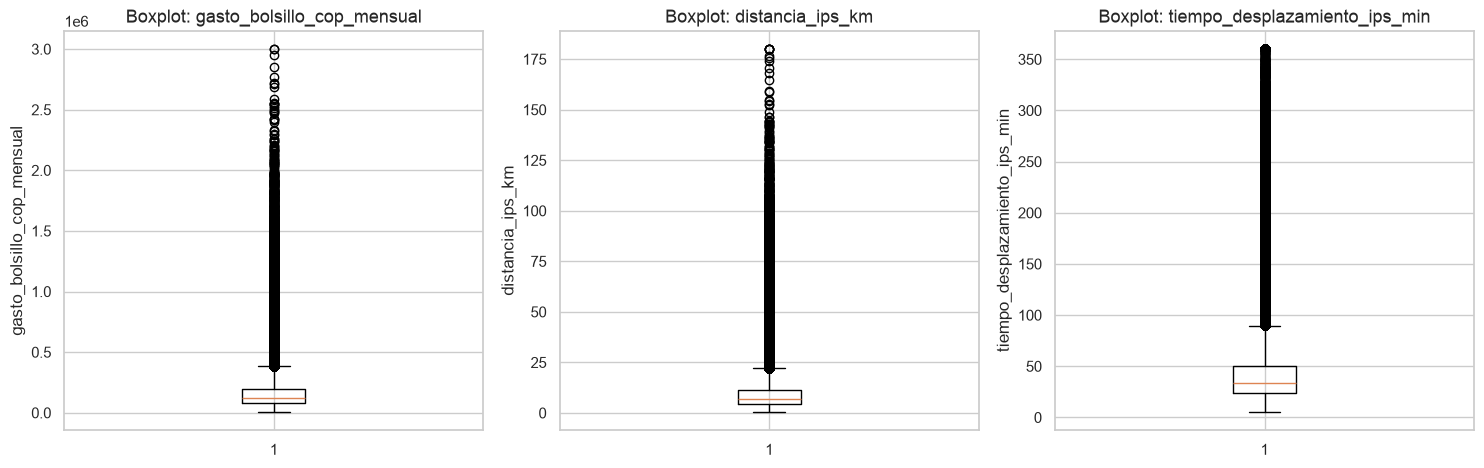


7. DETECCIÓN DE OUTLIERS (método IQR)
gasto_bolsillo_cop_mensual: 81,224 outliers (5.41%) — límites válidos [-106466.0, 383886.0]
distancia_ips_km: 90,791 outliers (6.05%) — límites válidos [-6.4, 22.1]
tiempo_desplazamiento_ips_min: 82,766 outliers (5.52%) — límites válidos [-15.0, 89.0]


In [7]:
# ============================================================
# 1. Distribución de la variable objetivo
# ============================================================
print("="*60)
print("1. VARIABLE OBJETIVO: hospitalizaciones_12m")
print("="*60)

print("\nDistribución de valores:")
print(df['hospitalizaciones_12m'].value_counts(normalize=True).sort_index().round(4))

proporcion_hospitalizados = (df['hospitalizaciones_12m'] > 0).mean()
print(f"\nProporción con AL MENOS 1 hospitalización: {proporcion_hospitalizados:.2%}")
print(f"Proporción SIN hospitalización: {1-proporcion_hospitalizados:.2%}")


# ============================================================
# 2. Verificación de redundancia (hospitalizacion_relacionada_12m)
# ============================================================
print("\n" + "="*60)
print("2. VERIFICACIÓN DE REDUNDANCIA")
print("="*60)

son_identicas = (df['hospitalizaciones_12m'] == df['hospitalizacion_relacionada_12m']).all()
print(f"¿hospitalizaciones_12m == hospitalizacion_relacionada_12m en TODAS las filas? {son_identicas}")

if not son_identicas:
    n_diferentes = (df['hospitalizaciones_12m'] != df['hospitalizacion_relacionada_12m']).sum()
    print(f"Número de filas donde difieren: {n_diferentes}")


# ============================================================
# 3. Desbalance de variables binarias clave (control_presion_arterial, riesgo_alto_12m)
# ============================================================
print("\n" + "="*60)
print("3. DESBALANCE DE VARIABLES BINARIAS CLAVE")
print("="*60)

for var in ['control_presion_arterial', 'control_glucemico', 'riesgo_alto_12m']:
    positivos = df[var].sum()
    total = len(df)
    print(f"{var}: {positivos:,} de {total:,} ({positivos/total:.2%})")


# ============================================================
# 4. Verificación de posible fuga de datos: riesgo_alto_12m vs hospitalizaciones_12m
# ============================================================
print("\n" + "="*60)
print("4. VERIFICACIÓN DE FUGA DE DATOS: riesgo_alto_12m")
print("="*60)

tabla_cruzada = pd.crosstab(
    df['hospitalizaciones_12m'] > 0,
    df['riesgo_alto_12m'],
    rownames=['Hospitalizado'],
    colnames=['riesgo_alto_12m']
)
print(tabla_cruzada)

# Si casi todos los hospitalizados tienen riesgo_alto_12m=1, hay fuga potencial
pct_hosp_con_riesgo_alto = df.loc[df['hospitalizaciones_12m'] > 0, 'riesgo_alto_12m'].mean()
print(f"\n% de hospitalizados que tienen riesgo_alto_12m=1: {pct_hosp_con_riesgo_alto:.2%}")


# ============================================================
# 5. Asimetría (skewness) de variables con posible sesgo
# ============================================================
print("\n" + "="*60)
print("5. ASIMETRÍA DE VARIABLES CON POSIBLE SESGO")
print("="*60)

variables_revisar = ['gasto_bolsillo_cop_mensual', 'distancia_ips_km', 'tiempo_desplazamiento_ips_min']

for var in variables_revisar:
    skew = df[var].skew()
    media = df[var].mean()
    mediana = df[var].median()
    print(f"{var}: skew={skew:.3f}, media={media:,.1f}, mediana={mediana:,.1f}")


# ============================================================
# 6. Boxplots de las variables con sesgo, para inspección visual de outliers
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables_revisar):
    axes[i].boxplot(df[var])
    axes[i].set_title(f"Boxplot: {var}")
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()


# ============================================================
# 7. Detección de outliers vía IQR (conteo, no eliminación)
# ============================================================
print("\n" + "="*60)
print("7. DETECCIÓN DE OUTLIERS (método IQR)")
print("="*60)

def contar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    return outliers, limite_inf, limite_sup

for var in variables_revisar:
    n_outliers, lim_inf, lim_sup = contar_outliers_iqr(df[var])
    pct_outliers = n_outliers / len(df) * 100
    print(f"{var}: {n_outliers:,} outliers ({pct_outliers:.2f}%) — límites válidos [{lim_inf:.1f}, {lim_sup:.1f}]")

In [8]:
# Confirmar que categoria_imc es perfectamente derivable de imc (sin ambigüedad)
print(df.groupby('categoria_imc')['imc'].agg(['min', 'max']))

                min   max
categoria_imc            
Normal         17.0  24.9
Obesidad_I     30.0  34.9
Obesidad_II    35.0  39.9
Obesidad_III   40.0  53.4
Sobrepeso      25.0  29.9


## 4.5. Conclusiones de la visión general

Antes de avanzar a la etapa de limpieza, resumimos los hallazgos obtenidos en esta sección:

**Dimensiones y estructura.** El conjunto de datos contiene **1.500.000 registros y 57 columnas**, todas con **0 valores nulos** (`Non-Null Count = 1.500.000` en las 57 columnas) y con el **tipo de dato correcto** desde el origen (numéricas como `int64`/`float64`, categóricas como `str`) — a diferencia del caso de referencia visto en clase (automóviles), este dataset **no presenta el problema de `?` mezclados** que fuerza columnas numéricas a texto.

**Variable objetivo.** `hospitalizaciones_12m` muestra un **desbalance de clases real y confirmado**: el 82.71% de los pacientes no tuvo ninguna hospitalización en 12 meses, y solo el **17.29%** tuvo al menos una. Este desbalance (más marcado del ~21% estimado originalmente en el planteamiento del problema) confirma la necesidad de aplicar, en la etapa de modelado, técnicas específicas para clases desbalanceadas (ajuste de pesos, remuestreo, y priorizar recall/AUC sobre accuracy).

**Columnas a excluir del conjunto de predictores, con evidencia verificada:**
- `id_registro`: identificador único (1.500.000 valores distintos), sin valor predictivo.
- `fecha_corte`: variable constante (1 único valor: `2026-08-01`), sin capacidad discriminativa.
- `hospitalizacion_relacionada_12m`: **confirmado con `True` en la comparación exhaustiva** — es idéntica a `hospitalizaciones_12m` en el 100% de las filas. Se descarta por redundancia total.
- `evento_cardiovascular_12m`, `muerte_12m`: **fuga de datos confirmada con evidencia directa** — la proporción de evento cardiovascular es 3.25% en no hospitalizados vs. 15.48% en hospitalizados (~4.8 veces más frecuente); la proporción de fallecimiento es 1.24% en no hospitalizados vs. 8.54% en hospitalizados (~6.9 veces más frecuente). Se excluyen del conjunto de predictores; además, ninguna hipótesis de trabajo (H1-H4) las contempla como predictoras.
- `riesgo_alto_12m`: sin evidencia clara de fuga de datos directa (97.09% en hospitalizados vs. 93.14% en no hospitalizados, diferencia pequeña), pero con desbalance extremo (93.81% de la población) que le confiere baja capacidad discriminativa; se excluye también por ser variable objetivo de otro subcaso, no contemplada en H1-H4.
- `categoria_imc`: variable categórica derivada directamente de `imc`, con rangos consecutivos y sin solapamiento entre categorías (Normal: 17.0-24.9; Sobrepeso: 25.0-29.9; Obesidad_I: 30.0-34.9; Obesidad_II: 35.0-39.9; Obesidad_III: 40.0-53.4) — confirmando una derivación determinística. Se excluye para evitar duplicar la misma señal en el modelo, conservando `imc` como la versión continua.

**Variables que SÍ se incorporan como predictoras (ajuste respecto a una versión anterior de este análisis):**
- `control_glucemico` y `control_presion_arterial` representan el estado clínico del paciente al momento del corte de datos, no un resultado posterior a la hospitalización — se incorporan como predictoras, dado que están contempladas explícitamente en la Hipótesis H2.

**Desbalances adicionales relevantes para las hipótesis de trabajo:**
- `control_presion_arterial` está presente en solo el **0.48%** de los pacientes — desbalance extremo que limita su uso como variable binaria en el análisis de H2; se priorizará el uso de `tension_sistolica_mmhg`/`tension_diastolica_mmhg` como variables continuas complementarias.
- `riesgo_alto_12m` etiqueta al **93.81%** de los pacientes como alto riesgo — consistente con baja capacidad discriminativa.

**Outliers detectados (método IQR) en variables de acceso y carga económica:**
- `gasto_bolsillo_cop_mensual`: 81.224 outliers (5.41%).
- `distancia_ips_km`: 90.791 outliers (6.05%) — variable clave para H4.
- `tiempo_desplazamiento_ips_min`: 82.766 outliers (5.52%) — variable clave para H4.

Estos porcentajes de outliers (5-6%) son moderados y consistentes con la naturaleza real de estas variables — no se recomienda eliminarlos automáticamente, ya que probablemente representan pacientes genuinamente alejados de su IPS (zona rural), información relevante precisamente para H4, no ruido a descartar.

**Estado del dataset antes de pasar a la limpieza:** dado que no existen valores faltantes ni columnas con tipo de dato incorrecto, la sección 5 (Limpieza) de este notebook —heredada del ejemplo de automóviles— requiere una adaptación sustancial: no aplican los pasos de reemplazo de `?`, imputación por media/moda, ni eliminación de filas por variable objetivo faltante. El foco de la limpieza para este dataset debe estar en: (1) la exclusión formal de las columnas identificadas arriba del conjunto de predictores, y (2) la codificación de variables categóricas y ordinales para su uso posterior en modelado.

---
# 5. Limpieza y preparación de los datos

> *Etapa del flujo: preparación previa al análisis (valores perdidos, formato)*

La calidad del análisis depende directamente de la calidad de los datos. A diferencia del caso de referencia visto en clase (automóviles), donde la limpieza se centraba en tres problemas concretos (valores perdidos codificados como `?`, columnas mal tipadas por esa razón, y unidades no estandarizadas), la visión general de este dataset (sección 4) **ya confirmó que ninguno de esos tres problemas está presente**:

1. **Valores perdidos:** `df.info()` mostró `Non-Null Count = 1.500.000` en las 57 columnas, sin ninguna excepción — el dataset sintético no contiene valores faltantes.
2. **Formato de los datos:** las columnas ya presentan el tipo correcto desde el origen (numéricas como `int64`/`float64`, categóricas como `str`), sin el problema de `?` mezclados que fuerza una columna numérica a interpretarse como texto.
3. **Unidades de medida:** las variables clínicas ya están expresadas en unidades estándar y consistentes (mmHg, mg/dL, kg/m², años, minutos), sin necesidad de conversión.

> **Advertencia profesional.** No todos los valores atípicos o sospechosos deben "corregirse". Algunos son genuinos desde el punto de vista del negocio. En un entorno real, conviene validar con el equipo de ingeniería de datos antes de modificar el conjunto original — esto aplica especialmente a los outliers de `distancia_ips_km` y `tiempo_desplazamiento_ips_min` ya identificados en la sección 4.5, que probablemente representan pacientes genuinamente alejados de su IPS, información relevante para la Hipótesis H4, no ruido a eliminar.

Dado que los tres problemas típicos de limpieza no aplican a este dataset, el foco de esta sección se traslada a dos tareas identificadas como pendientes en las conclusiones de la sección 4:

## 5.1. Verificación de ausencia de valores perdidos

Aunque `df.info()` ya lo sugirió, verificamos formalmente que no existan valores nulos en ninguna columna, siguiendo el mismo estándar de rigor aplicado en el resto del notebook.

In [9]:
# Verificación explícita de valores nulos en el dataset completo
total_faltantes = df.isnull().sum().sum()
print("Total de valores perdidos en el dataset:", total_faltantes)
assert total_faltantes == 0, "Se encontraron valores perdidos no anticipados."
print("Confirmado: el conjunto de datos no contiene valores perdidos.")

Total de valores perdidos en el dataset: 0
Confirmado: el conjunto de datos no contiene valores perdidos.


## 5.2. Codificación de variables categóricas y ordinales

Para su uso posterior en modelado, las variables categóricas del dataset requieren codificación numérica. Se distinguen dos casos, siguiendo la misma lógica aplicada en el análisis del dataset de enfermedad cardíaca visto en clase:

- **Variables nominales** (sin orden inherente entre categorías): `departamento`, `zona`, `sexo`, `nivel_socioeconomico` (opcionalmente ordinal), `regimen_afiliacion`, `nivel_educativo` (opcionalmente ordinal), `estado_civil`, `situacion_laboral`, `tipo_vivienda`, `diabetes_tipo`, `tabaquismo`, `alcohol_frecuencia`, `medicamento_antidiabetico_principal`, `medicamento_antihipertensivo_principal` — candidatas a **one-hot encoding** (variables dummy).
- **Variables ordinales** (con orden inherente): `grupo_edad`, `albuminuria_categoria` (A1 < A2 < A3, severidad creciente) — candidatas a **codificación ordinal**, preservando el orden en vez de tratarlas como categorías sin relación entre sí.

Esta codificación se documenta aquí como paso identificado, y se ejecutará al inicio de la etapa de modelado (fuera del alcance del presente EDA), dado que la elección específica de técnica (one-hot vs. ordinal vs. target encoding) puede depender del algoritmo que finalmente se seleccione.

## 5.3. Exclusión formal del conjunto de predictores

Con base en el análisis de columnas redundantes, identificadores y *data leakage* realizado en la sección 4.3, y consolidado en las conclusiones de la sección 4.5, se construye explícitamente el conjunto de predictores válidos para el resto del análisis, sin modificar el DataFrame original.

In [10]:
# Variable objetivo del proyecto
variable_objetivo = 'hospitalizaciones_12m'

# Columnas excluidas del conjunto de predictores, con su justificación documentada en 4.5
columnas_excluir_predictores = [
    'id_registro',                      # identificador, sin valor predictivo
    'fecha_corte',                      # constante, sin variabilidad
    'hospitalizacion_relacionada_12m',  # redundante con la variable objetivo (100% idéntica)
    'evento_cardiovascular_12m',        # fuga de datos confirmada (4.8x más frecuente en hospitalizados)
    'muerte_12m',                       # fuga de datos confirmada (6.9x más frecuente en hospitalizados)
    'riesgo_alto_12m',                  # variable objetivo de otro subcaso, baja capacidad discriminativa
    'categoria_imc',                    # redundante con imc (derivación determinística confirmada)
]

predictores_candidatos = [
    col for col in df.columns
    if col not in columnas_excluir_predictores + [variable_objetivo]
]

print(f"Total de columnas originales: {df.shape[1]}")
print(f"Columnas excluidas: {len(columnas_excluir_predictores)}")
print(f"Total de predictores candidatos: {len(predictores_candidatos)}")
print(predictores_candidatos)

Total de columnas originales: 57
Columnas excluidas: 7
Total de predictores candidatos: 49
['departamento', 'zona', 'sexo', 'edad_anios', 'grupo_edad', 'nivel_socioeconomico', 'regimen_afiliacion', 'nivel_educativo', 'estado_civil', 'situacion_laboral', 'personas_hogar', 'tipo_vivienda', 'diabetes_tipo', 'anios_desde_dx_diabetes', 'anios_desde_dx_hipertension', 'imc', 'perimetro_abdominal_cm', 'tabaquismo', 'cigarrillos_dia', 'alcohol_frecuencia', 'actividad_fisica_min_sem', 'calidad_dieta_0_100', 'horas_sueno', 'estres_0_10', 'adherencia_tratamiento_0_100', 'consultas_atencion_primaria_12m', 'urgencias_12m', 'gasto_bolsillo_cop_mensual', 'distancia_ips_km', 'tiempo_desplazamiento_ips_min', 'tension_sistolica_mmhg', 'tension_diastolica_mmhg', 'hba1c_pct', 'glucosa_ayunas_mg_dl', 'colesterol_ldl_mg_dl', 'trigliceridos_mg_dl', 'egfr_ml_min_1_73m2', 'albuminuria_categoria', 'medicamento_antidiabetico_principal', 'usa_insulina', 'medicamento_antihipertensivo_principal', 'usa_estatina', 'co

## 5.4. Recodificación de la variable objetivo a binaria

El proyecto define la predicción de hospitalización como un problema de clasificación binaria (¿el paciente será hospitalizado o no en los próximos 12 meses?), no de conteo del número exacto de hospitalizaciones. Se recodifica `hospitalizaciones_12m` en consecuencia, conservando la versión original de conteo por si se requiere en algún análisis complementario.

In [11]:
# Recodificación a binaria: 1 = al menos una hospitalización, 0 = ninguna
df['hospitalizado_12m'] = (df['hospitalizaciones_12m'] > 0).astype(int)

print("Distribución de la variable objetivo binaria (hospitalizado_12m):")
print(df['hospitalizado_12m'].value_counts(normalize=True).round(4))
print(f"\nProporción con al menos 1 hospitalización: {df['hospitalizado_12m'].mean():.2%}")

Distribución de la variable objetivo binaria (hospitalizado_12m):
hospitalizado_12m
0    0.8271
1    0.1729
Name: proportion, dtype: float64

Proporción con al menos 1 hospitalización: 17.29%


## Conclusión general — Sección 5: Limpieza y preparación de los datos

**Estado del dataset tras la etapa de limpieza.** A diferencia del caso de referencia visto en clase (automóviles), donde la limpieza requería resolver tres problemas concretos (valores perdidos codificados con `?`, columnas mal tipadas por esa razón, y unidades no estandarizadas), este dataset llegó a la etapa de limpieza ya libre de esos tres problemas — confirmado formalmente con la verificación de `total_faltantes == 0` sobre las 1.500.000 filas y 57 columnas. Por esta razón, el trabajo de esta sección no se centró en corregir defectos de calidad, sino en **preparar el dataset para el análisis y modelado posteriores**, a través de cuatro decisiones documentadas:

**1. Verificación de calidad (5.1).** Se confirmó formalmente la ausencia de valores perdidos en la totalidad del dataset, descartando la necesidad de cualquier estrategia de imputación o eliminación de filas.

**2. Codificación de variables categóricas y ordinales (5.2).** Se documentó la estrategia a seguir en la etapa de modelado, distinguiendo variables nominales (sin orden inherente, candidatas a one-hot encoding) de variables ordinales (`grupo_edad`, `albuminuria_categoria`, con orden clínico real, candidatas a codificación ordinal que preserve ese orden).

**3. Exclusión formal del conjunto de predictores (5.3).** Con base en la evidencia recolectada en la sección 4 (valores únicos, redundancia exacta, tablas cruzadas de fuga de datos), se excluyeron 7 columnas del conjunto de predictores: `id_registro` y `fecha_corte` (sin capacidad discriminativa), `hospitalizacion_relacionada_12m` (redundante en el 100% de las filas), `evento_cardiovascular_12m` y `muerte_12m` (fuga de datos confirmada, con proporciones 4.8 y 6.9 veces más frecuentes entre hospitalizados), `riesgo_alto_12m` (baja capacidad discriminativa por desbalance extremo) y `categoria_imc` (redundante con `imc`). El resultado es un conjunto de predictores candidatos explícito y trazable, sin modificar el DataFrame original.

**4. Recodificación de la variable objetivo (5.4).** Se transformó `hospitalizaciones_12m` (conteo) en `hospitalizado_12m` (binaria), alineando la variable objetivo con el enfoque de clasificación binaria definido en la Pregunta SMART del proyecto, conservando la variable de conteo original disponible para análisis complementarios si se requieren.

**Conclusión.** El dataset queda, al cierre de esta sección, en condiciones de avanzar al análisis univariado y bivariado: completo, sin ambigüedades de tipo de dato, con un conjunto de predictores depurado de redundancias y riesgos de fuga de datos, y con la variable objetivo ya preparada en el formato requerido por el problema de clasificación binaria planteado en la Pregunta SMART.

---
# 6. Análisis univariado

> *Etapa del flujo: **Análisis univariado** — para cada variable: faltantes, outliers y distribución*

El análisis univariado estudia **una variable a la vez**. Su propósito es comprender, para cada atributo, su **distribución**, su **tendencia central**, su **dispersión** y la presencia de **valores atípicos (outliers)**. Distinguimos el tratamiento según el tipo de variable:

- **Variables numéricas continuas:** examinamos outliers y forma de la distribución mediante histogramas y boxplots.
- **Variables categóricas y ordinales:** examinamos qué categorías existen y con qué frecuencia aparecen, mediante gráficos de barras.

Trabajamos exclusivamente sobre el conjunto de `predictores_candidatos` definido en la sección 5.3, más la variable objetivo `hospitalizado_12m` preparada en la sección 5.4 — evitando así describir columnas ya excluidas por redundancia o riesgo de fuga de datos.

In [12]:
# Clasificamos las columnas del conjunto de predictores en numéricas y categóricas.
df_analisis = df[predictores_candidatos + ['hospitalizado_12m']]

variables_numericas = df_analisis.select_dtypes(include=[np.number]).columns.tolist()
variables_numericas.remove('hospitalizado_12m')  # se analiza aparte, como variable objetivo

variables_categoricas = df_analisis.select_dtypes(include=["object", "str"]).columns.tolist()

print("Variables NUMÉRICAS ({}):".format(len(variables_numericas)))
print(variables_numericas)
print("\nVariables CATEGÓRICAS ({}):".format(len(variables_categoricas)))
print(variables_categoricas)

Variables NUMÉRICAS (33):
['edad_anios', 'personas_hogar', 'anios_desde_dx_diabetes', 'anios_desde_dx_hipertension', 'imc', 'perimetro_abdominal_cm', 'cigarrillos_dia', 'actividad_fisica_min_sem', 'calidad_dieta_0_100', 'horas_sueno', 'estres_0_10', 'adherencia_tratamiento_0_100', 'consultas_atencion_primaria_12m', 'urgencias_12m', 'gasto_bolsillo_cop_mensual', 'distancia_ips_km', 'tiempo_desplazamiento_ips_min', 'tension_sistolica_mmhg', 'tension_diastolica_mmhg', 'hba1c_pct', 'glucosa_ayunas_mg_dl', 'colesterol_ldl_mg_dl', 'trigliceridos_mg_dl', 'egfr_ml_min_1_73m2', 'usa_insulina', 'usa_estatina', 'comorbilidad_erc', 'comorbilidad_dislipidemia', 'comorbilidad_obesidad', 'complicacion_diabetes_previa', 'riesgo_cv_10_anios_pct', 'control_glucemico', 'control_presion_arterial']

Variables CATEGÓRICAS (16):
['departamento', 'zona', 'sexo', 'grupo_edad', 'nivel_socioeconomico', 'regimen_afiliacion', 'nivel_educativo', 'estado_civil', 'situacion_laboral', 'tipo_vivienda', 'diabetes_tipo',

## 6.1. La variable objetivo: `hospitalizado_12m`

Iniciamos por la variable que deseamos predecir. Comprender su distribución es esencial: nos dice qué tan desbalanceadas están las clases, información que condiciona directamente la elección de métricas y técnicas en la etapa de modelado (ver conclusiones de la sección 4.5).

hospitalizado_12m
0    0.8271
1    0.1729
Name: proportion, dtype: float64


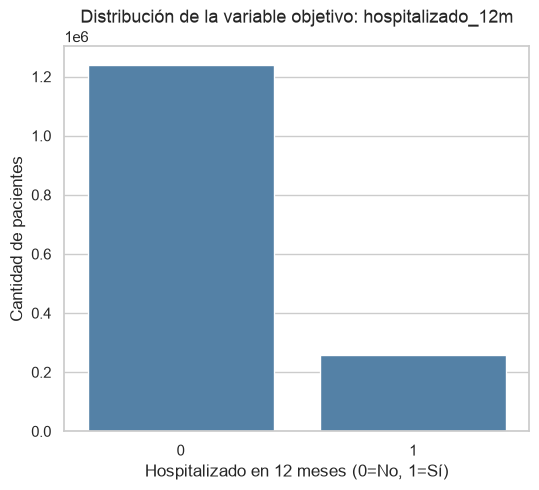

In [13]:
# Estadísticos descriptivos de la variable objetivo
print(df_analisis["hospitalizado_12m"].value_counts(normalize=True).round(4))

# Gráfico de barras de la variable objetivo (es binaria, no continua -> no aplica histograma/boxplot)
plt.figure(figsize=(6, 5))
sns.countplot(x=df_analisis["hospitalizado_12m"], color="steelblue")
plt.title("Distribución de la variable objetivo: hospitalizado_12m")
plt.xlabel("Hospitalizado en 12 meses (0=No, 1=Sí)")
plt.ylabel("Cantidad de pacientes")
plt.show()

**Interpretación.** La variable objetivo está **fuertemente desbalanceada**: el 82.71% de los pacientes no presentó ninguna hospitalización en 12 meses, frente al 17.29% que sí. Este desbalance, ya cuantificado en la sección 4.5, deberá tenerse en cuenta al modelar (por ejemplo, mediante ajuste de pesos de clase, remuestreo, o priorizando métricas como recall/AUC sobre accuracy).

## 6.2. Variables numéricas continuas y de conteo

Analizamos las variables numéricas con **expectativa Alta** según el diccionario de datos (sección 3.1) — `adherencia_tratamiento_0_100`, `hba1c_pct`, `egfr_ml_min_1_73m2`, `tension_sistolica_mmhg` y `tension_diastolica_mmhg` (**continuas**), junto con `urgencias_12m` (**conteo discreto**) — estudiando su distribución y sus outliers de forma sistemática, reutilizando la misma función auxiliar del taller de referencia. Incluimos `urgencias_12m` en este bloque por su alta expectativa predictiva; no obstante, al tratarse de una variable de conteo con abundancia de ceros, su distribución e interpretación difieren de las continuas (como se detalla en la interpretación siguiente y en la sección 7.4.2).

===== adherencia_tratamiento_0_100 =====
count    1500000.00
mean          68.88
std           16.66
min            5.00
25%           57.50
50%           69.10
75%           80.70
max          100.00
Name: adherencia_tratamiento_0_100, dtype: float64


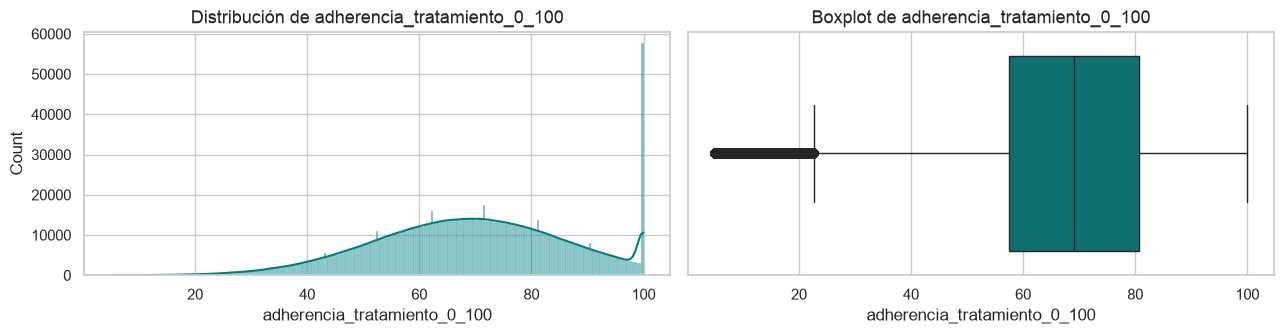

===== hba1c_pct =====
count    1500000.00
mean           8.28
std            1.18
min            5.20
25%            7.50
50%            8.30
75%            9.10
max           14.10
Name: hba1c_pct, dtype: float64


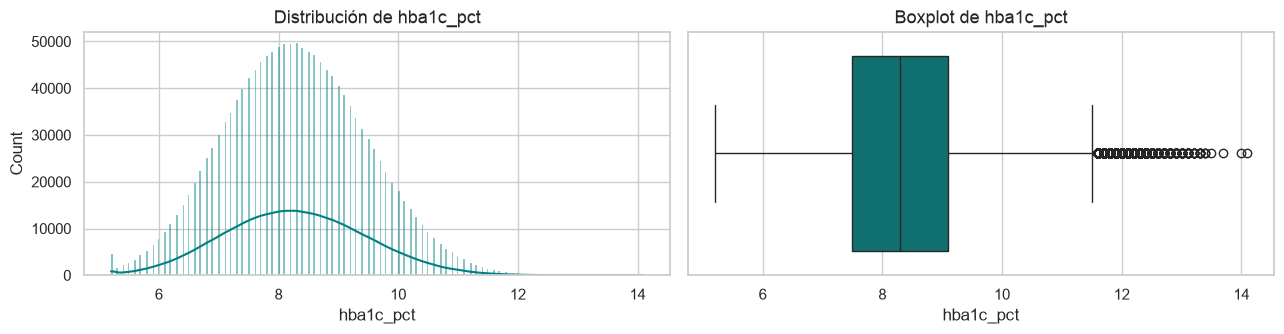

===== egfr_ml_min_1_73m2 =====
count    1500000.00
mean          58.91
std           21.85
min            8.00
25%           43.20
50%           59.60
75%           75.00
max          130.00
Name: egfr_ml_min_1_73m2, dtype: float64


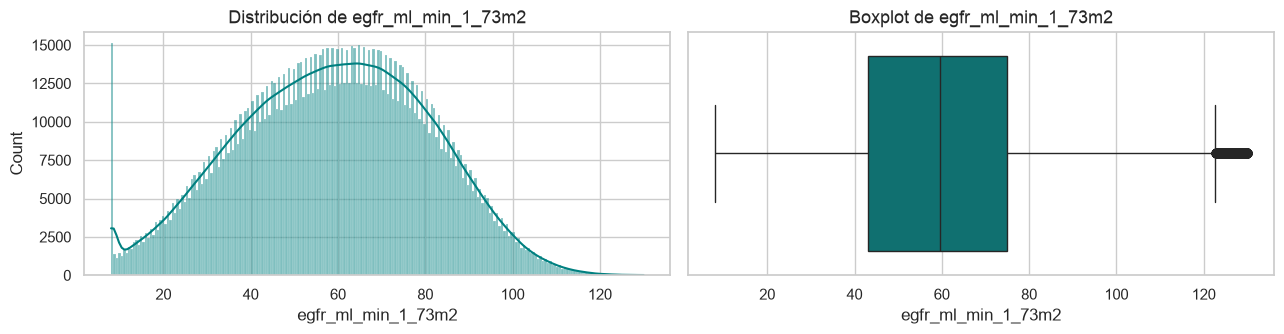

===== tension_sistolica_mmhg =====
count    1500000.00
mean         165.58
std           12.66
min          104.00
25%          157.00
50%          166.00
75%          174.00
max          227.00
Name: tension_sistolica_mmhg, dtype: float64


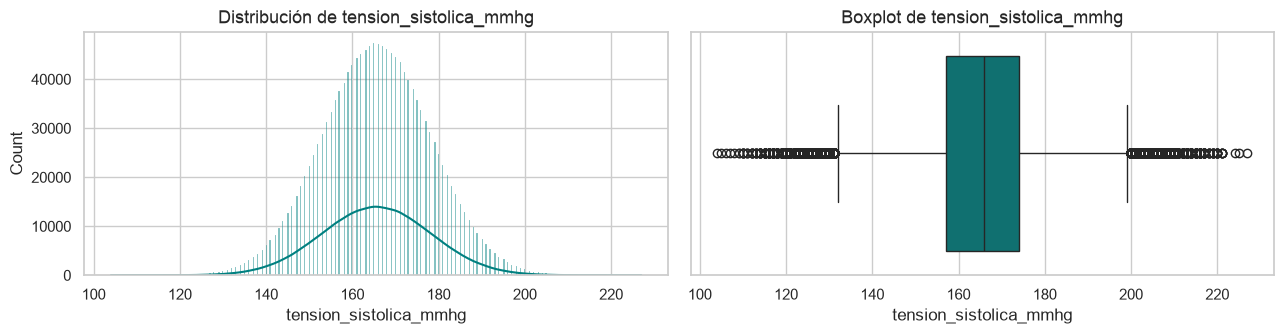

===== tension_diastolica_mmhg =====
count    1500000.00
mean          96.30
std            8.16
min           57.00
25%           91.00
50%           96.00
75%          102.00
max          134.00
Name: tension_diastolica_mmhg, dtype: float64


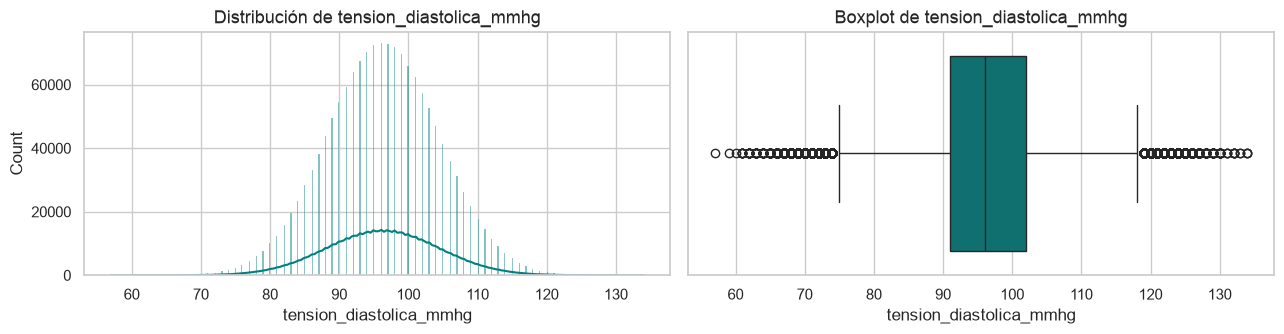

===== urgencias_12m =====
count    1500000.00
mean           0.41
std            0.69
min            0.00
25%            0.00
50%            0.00
75%            1.00
max            8.00
Name: urgencias_12m, dtype: float64


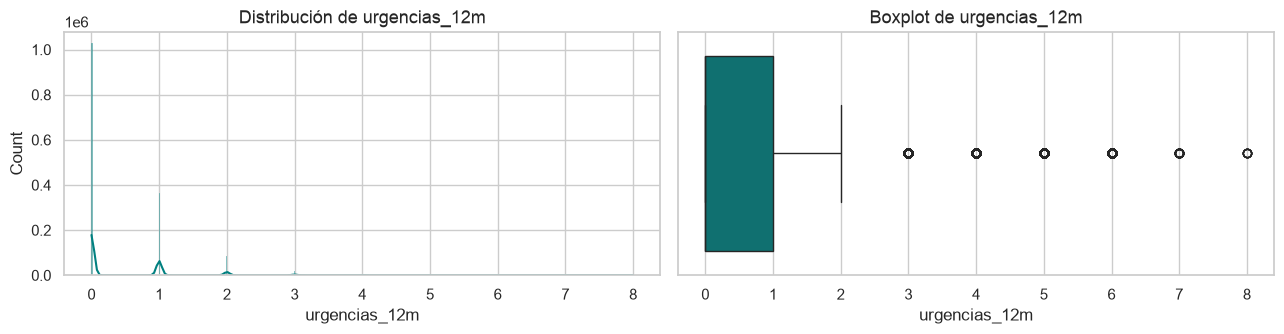

In [14]:
def analizar_variable_continua(columna):
    """Muestra estadísticos, histograma y boxplot de una variable continua."""
    print(f"===== {columna} =====")
    print(df_analisis[columna].describe().round(2))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
    sns.histplot(df_analisis[columna], kde=True, ax=ax1, color="teal")
    ax1.set_title(f"Distribución de {columna}")
    sns.boxplot(x=df_analisis[columna], ax=ax2, color="teal")
    ax2.set_title(f"Boxplot de {columna}")
    plt.tight_layout()
    plt.show()

variables_alta_expectativa = [
    "adherencia_tratamiento_0_100", "hba1c_pct", "egfr_ml_min_1_73m2",
    "tension_sistolica_mmhg", "tension_diastolica_mmhg", "urgencias_12m"
]

for var in variables_alta_expectativa:
    analizar_variable_continua(var)

**Interpretación de las variables continuas.**

- **`adherencia_tratamiento_0_100`:** distribución con forma aproximadamente acampanada centrada alrededor de 65-70, pero con un **pico atípico muy marcado en 100** (el máximo posible) — un subgrupo considerable de pacientes reporta adherencia perfecta, rompiendo la forma suave del resto de la distribución. El boxplot muestra outliers concentrados en el extremo **inferior** (adherencia muy baja, cercana a 5-20), que son precisamente los pacientes de mayor interés para la Hipótesis H1.

- **`hba1c_pct`:** distribución aproximadamente **normal/simétrica**, centrada en 8.3%, con media (8.28) y mediana (8.30) casi idénticas. Los outliers detectados están concentrados en el extremo **superior** (valores >11.5%), reflejando pacientes con descontrol glucémico severo — clínicamente plausibles, no errores de captura. Relevante para H2: la mayoría de la cohorte está por encima del umbral de control (7%).

- **`egfr_ml_min_1_73m2`:** distribución con forma de campana ligeramente sesgada, pero con un **pico anómalo cerca del valor mínimo (~8)**, similar al patrón de `adherencia_tratamiento_0_100` — sugiere un subgrupo de pacientes con falla renal severa concentrado en el límite inferior de la escala. El boxplot no muestra outliers superiores relevantes; la variabilidad se concentra en el rango medio-bajo, consistente con una cohorte con deterioro renal significativo (H3).

- **`tension_sistolica_mmhg`** y **`tension_diastolica_mmhg`:** ambas presentan distribuciones **aproximadamente normales**, centradas en 166 mmHg y 96 mmHg respectivamente — muy por encima de los umbrales de control (140/90 mmHg), confirmando visualmente el hallazgo ya cuantificado de que solo el 0.48% de los pacientes tiene la presión controlada. Ambas muestran outliers simétricos en ambos extremos (valores muy bajos y muy altos), sin sesgo marcado hacia un solo lado.

- **`urgencias_12m`:** distribución **extremadamente sesgada a la derecha** — la inmensa mayoría de pacientes (más del 75%, según el describe()) no tuvo ninguna atención por urgencias en 12 meses, con una cola larga y delgada hacia valores de 3 a 8. El boxplot marca como "outliers" prácticamente todos los valores ≥3, un patrón típico de variables de conteo con muchos ceros — no son errores, sino la naturaleza esperada de una variable de utilización de servicios en una cohorte donde la mayoría no se descompensa.

**Patrón transversal a destacar:** tres de las seis variables (`adherencia_tratamiento_0_100`, `egfr_ml_min_1_73m2`, `urgencias_12m`) muestran picos anómalos concentrados en un extremo de su rango, en vez de una forma suave — esto sugiere la presencia de subgrupos de pacientes con perfiles clínicos extremos dentro de la cohorte (adherencia perfecta o nula, función renal muy deteriorada, utilización de urgencias frecuente), lo cual será relevante al construir el análisis bivariado frente a `hospitalizado_12m` en la sección 7.

### 6.2.1. Cuantificación de outliers mediante el rango intercuartílico (IQR)

El boxplot identifica visualmente los outliers. Para cuantificarlos formalmente empleamos la **regla del IQR**: se consideran atípicos los valores por debajo de `Q1 − 1.5·IQR` o por encima de `Q3 + 1.5·IQR`. Incluimos además `distancia_ips_km`, `tiempo_desplazamiento_ips_min` y `gasto_bolsillo_cop_mensual`, ya identificadas con outliers moderados en la sección 4.5.

In [15]:
def contar_outliers_iqr(columna):
    """Cuenta los outliers de una columna según la regla del IQR."""
    Q1 = df_analisis[columna].quantile(0.25)
    Q3 = df_analisis[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = df_analisis[(df_analisis[columna] < lim_inf) | (df_analisis[columna] > lim_sup)]
    return len(outliers)

variables_revisar_outliers = variables_alta_expectativa + [
    "distancia_ips_km", "tiempo_desplazamiento_ips_min", "gasto_bolsillo_cop_mensual"
]

resumen_outliers = pd.DataFrame({
    "variable": variables_revisar_outliers,
    "n_outliers": [contar_outliers_iqr(v) for v in variables_revisar_outliers],
})
resumen_outliers["pct_outliers"] = (resumen_outliers["n_outliers"] / len(df_analisis) * 100).round(2)
resumen_outliers = resumen_outliers.sort_values("pct_outliers", ascending=False)

print(resumen_outliers.to_string(index=False))

                     variable  n_outliers  pct_outliers
             distancia_ips_km       90791          6.05
tiempo_desplazamiento_ips_min       82766          5.52
   gasto_bolsillo_cop_mensual       81224          5.41
                urgencias_12m       23435          1.56
       tension_sistolica_mmhg       10765          0.72
      tension_diastolica_mmhg       10410          0.69
 adherencia_tratamiento_0_100        5237          0.35
                    hba1c_pct        4997          0.33
           egfr_ml_min_1_73m2         392          0.03


**Nota metodológica.** La detección de outliers **no implica** su eliminación automática. Muchos de estos valores son genuinos: un paciente con `tiempo_desplazamiento_ips_min` muy alto puede reflejar una barrera de acceso real (relevante para H4), no un error de captura. La decisión de tratarlos se toma en la etapa de modelado y en función del objetivo de negocio.

## 6.3. Variables categóricas

Para las variables categóricas, el análisis univariado consiste en examinar **qué categorías existen** y **con qué frecuencia** aparecen. Utilizamos gráficos de barras. Analizamos las de mayor relevancia para las hipótesis de trabajo: `zona` y `nivel_socioeconomico` (H4), `albuminuria_categoria` (H3, ordinal), y `grupo_edad` (perfil general de la cohorte).

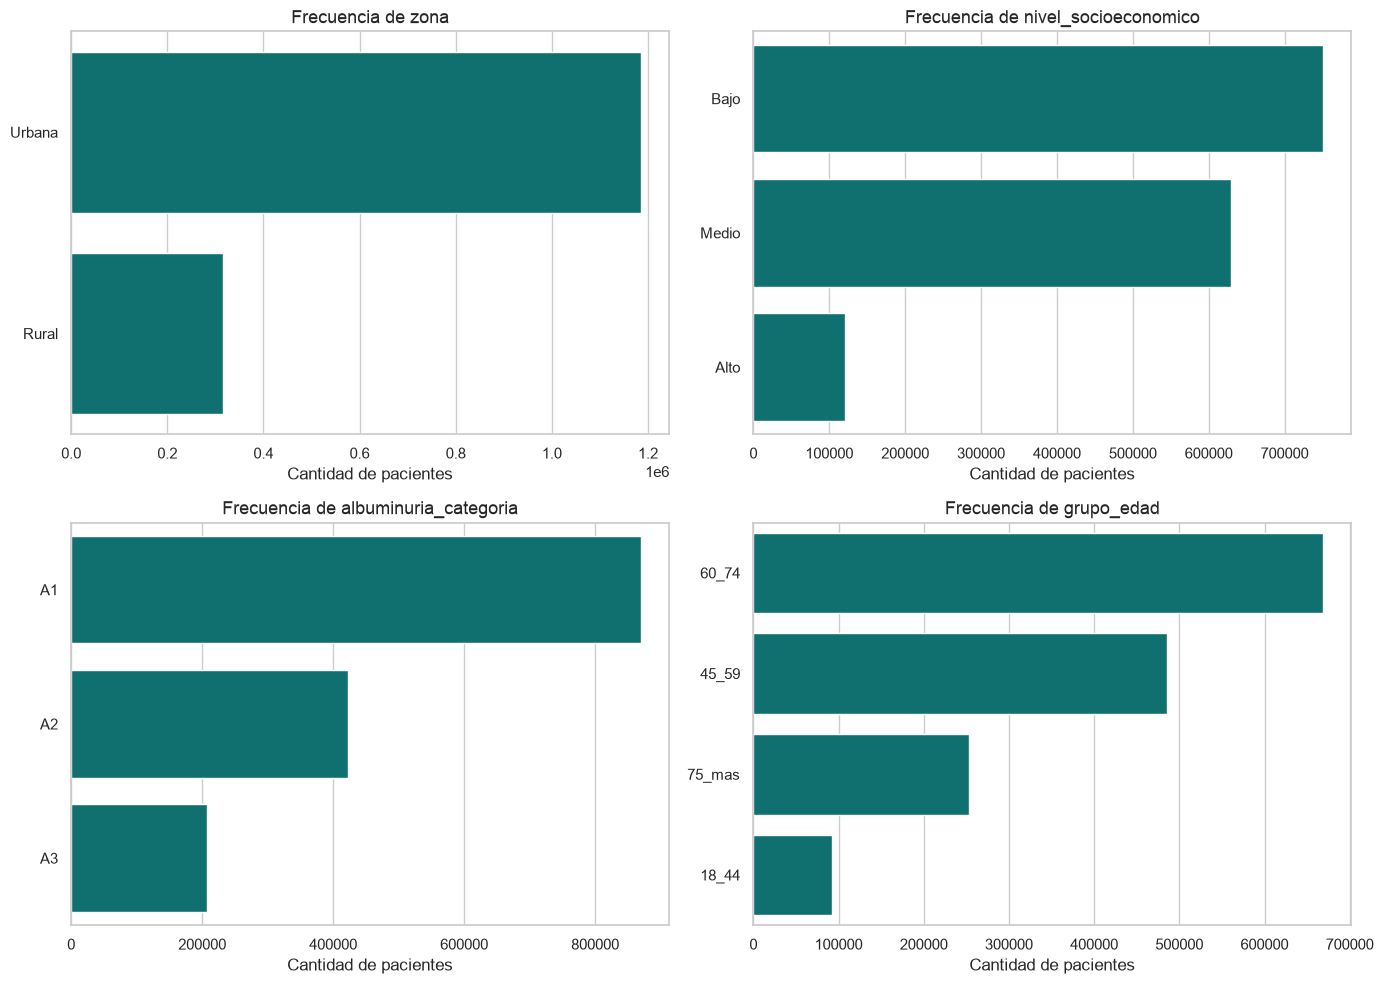

In [16]:
def analizar_variable_categorica(columna, ax):
    """Grafica la frecuencia de cada categoría de una variable."""
    orden = df_analisis[columna].value_counts().index
    sns.countplot(y=df_analisis[columna], order=orden, ax=ax, color="teal")
    ax.set_title(f"Frecuencia de {columna}")
    ax.set_xlabel("Cantidad de pacientes")
    ax.set_ylabel("")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), ["zona", "nivel_socioeconomico", "albuminuria_categoria", "grupo_edad"]):
    analizar_variable_categorica(col, ax)
plt.tight_layout()
plt.show()

In [17]:
# Tablas de frecuencia detalladas para las variables categóricas clave.
for col in ["zona", "nivel_socioeconomico", "albuminuria_categoria", "grupo_edad",
            "comorbilidad_erc", "complicacion_diabetes_previa"]:
    print(f"----- {col} -----")
    print(df_analisis[col].value_counts())
    print()

----- zona -----
zona
Urbana    1184842
Rural      315158
Name: count, dtype: int64

----- nivel_socioeconomico -----
nivel_socioeconomico
Bajo     750504
Medio    629321
Alto     120175
Name: count, dtype: int64

----- albuminuria_categoria -----
albuminuria_categoria
A1    869611
A2    422744
A3    207645
Name: count, dtype: int64

----- grupo_edad -----
grupo_edad
60_74     668590
45_59     485301
75_mas    253633
18_44      92476
Name: count, dtype: int64

----- comorbilidad_erc -----
comorbilidad_erc
0    921301
1    578699
Name: count, dtype: int64

----- complicacion_diabetes_previa -----
complicacion_diabetes_previa
0    840439
1    659561
Name: count, dtype: int64



**Interpretación de las variables categóricas.**

- **`zona`:** predomina claramente la zona **Urbana** (1.184.842 pacientes, 79.0%) sobre la **Rural** (315.158, 21.0%). Aunque la mayoría vive en zona urbana, el subgrupo rural (~315 mil pacientes) es suficientemente grande para sostener comparaciones estadísticas sólidas en el análisis bivariado de H4.

- **`nivel_socioeconomico`:** distribución concentrada en los niveles **Bajo** (750.504, 50.0%) y **Medio** (629.321, 42.0%), con el nivel **Alto** siendo claramente minoritario (120.175, 8.0%). Esta composición es coherente con el perfil típico de afiliados a regímenes subsidiado/contributivo de bajos ingresos en el sistema de salud colombiano.

- **`albuminuria_categoria`:** la mayoría de pacientes se ubica en **A1** (869.611, 58.0% — función renal normal o levemente alterada), seguida de **A2** (422.744, 28.2%) y **A3** (207.645, 13.8% — daño renal severo). Al ser una variable ordinal con orden clínico real (A1 < A2 < A3 en severidad), esta distribución será clave para el análisis bivariado de H3.

- **`grupo_edad`:** la cohorte está dominada por adultos mayores: **60-74 años** es el grupo más numeroso (668.590, 44.6%), seguido de **45-59** (485.301, 32.4%) y **75 y más** (253.633, 16.9%). El grupo **18-44** es claramente minoritario (92.476, apenas 6.2%) — coherente con que diabetes e hipertensión son condiciones más prevalentes en población de mayor edad.

- **`comorbilidad_erc`:** el **38.6%** de los pacientes (578.699) presenta enfermedad renal crónica como comorbilidad — una prevalencia considerable, consistente con el promedio de `egfr_ml_min_1_73m2` (58.9) ya observado en la sección 6.2, que sugería deterioro renal significativo en la cohorte.

- **`complicacion_diabetes_previa`:** el **44.0%** de los pacientes (659.561) tiene antecedente de al menos una complicación previa asociada a diabetes — una proporción alta, relevante directamente para la Hipótesis H3.

**Balance general:** a diferencia de la variable objetivo (fuertemente desbalanceada, 82.71%/17.29%), las variables categóricas analizadas presentan un balance razonable entre sus categorías —ninguna con una minoría extrema por debajo del 5%—, lo cual es favorable para el análisis bivariado que sigue: hay suficiente representación en cada grupo para comparar tasas de hospitalización de forma estadísticamente robusta.

---
# 7. Análisis bivariado

> *Etapa del flujo: **Análisis bivariado***

El análisis bivariado estudia la relación entre dos variables. Es el corazón de nuestra investigación, pues aquí examinamos directamente cómo se relaciona cada atributo con la variable objetivo hospitalizado_12m, contrastando así las hipótesis planteadas al inicio.

Según los tipos de variables involucradas, empleamos técnicas distintas:

- **Continua vs. continua:** diagramas de dispersión y coeficiente de correlación.
- **Categórica vs. continua:** boxplots comparativos por categoría.

## 7.1. Correlación de variables numéricas con la variable objetivo

Dado que algunas variables mostraron distribuciones con picos anómalos en la sección 6.2 (posible señal de relaciones no lineales), no nos limitamos a la correlación de Pearson. Calculamos tres métricas complementarias, cada una sensible a un tipo distinto de relación:

- **Pearson:** detecta solo relación lineal.
- **Spearman:** detecta relación monótona (no necesariamente lineal), usando rangos — más apropiado además para variables ordinales.
- **Información Mutua:** detecta cualquier forma de dependencia, lineal o no.

**Nota de rendimiento:** con 1.500.000 filas, se omite Kendall (su cálculo exacto es computacionalmente costoso a esta escala) y la Información Mutua se calcula sobre una muestra aleatoria representativa, en vez de la totalidad de los datos, sin pérdida relevante de precisión.

In [18]:
from sklearn.feature_selection import mutual_info_classif

y = df_analisis['hospitalizado_12m']
X_num = df_analisis[variables_numericas]

# Pearson y Spearman: rápidos, se calculan sobre el dataset completo
pearson_corr = X_num.corrwith(y, method='pearson')
spearman_corr = X_num.corrwith(y, method='spearman')

# Información Mutua: costosa, se calcula sobre una muestra aleatoria
muestra = df_analisis.sample(n=100_000, random_state=42)
mi_scores = mutual_info_classif(
    muestra[variables_numericas], muestra['hospitalizado_12m'],
    discrete_features=False, random_state=42
)
mi_corr = pd.Series(mi_scores, index=variables_numericas)

print("Métricas calculadas correctamente.")

Métricas calculadas correctamente.


In [19]:
tabla_correlacion = pd.DataFrame({
    "Pearson": pearson_corr,
    "Spearman": spearman_corr,
    "Info. Mutua": mi_corr,
})
tabla_correlacion["|Pearson|"] = tabla_correlacion["Pearson"].abs()
tabla_correlacion = tabla_correlacion.sort_values("|Pearson|", ascending=False).drop(columns="|Pearson|")

print("Correlación de cada variable numérica con hospitalizado_12m:\n")
print(tabla_correlacion.round(4).to_string())

Correlación de cada variable numérica con hospitalizado_12m:

                                 Pearson  Spearman  Info. Mutua
comorbilidad_erc                  0.1878    0.1878       0.0244
complicacion_diabetes_previa      0.1600    0.1600       0.0212
riesgo_cv_10_anios_pct            0.1556    0.1560       0.0105
egfr_ml_min_1_73m2               -0.1509   -0.1524       0.0119
anios_desde_dx_diabetes           0.1328    0.1344       0.0073
edad_anios                        0.1103    0.1102       0.0070
urgencias_12m                     0.1072    0.0905       0.0051
hba1c_pct                         0.0979    0.0974       0.0054
anios_desde_dx_hipertension       0.0810    0.0801       0.0038
glucosa_ayunas_mg_dl              0.0723    0.0715       0.0000
consultas_atencion_primaria_12m   0.0590    0.0584       0.0029
control_glucemico                -0.0557   -0.0557       0.0027
tension_sistolica_mmhg            0.0245    0.0239       0.0000
comorbilidad_dislipidemia         0.0228  

In [20]:
print("Top 10 por |Pearson|:")
print(pearson_corr.abs().sort_values(ascending=False).head(10).round(4))

print("\nTop 10 por |Spearman|:")
print(spearman_corr.abs().sort_values(ascending=False).head(10).round(4))

print("\nTop 10 por Información Mutua:")
print(mi_corr.sort_values(ascending=False).head(10).round(4))

Top 10 por |Pearson|:
comorbilidad_erc                0.1878
complicacion_diabetes_previa    0.1600
riesgo_cv_10_anios_pct          0.1556
egfr_ml_min_1_73m2              0.1509
anios_desde_dx_diabetes         0.1328
edad_anios                      0.1103
urgencias_12m                   0.1072
hba1c_pct                       0.0979
anios_desde_dx_hipertension     0.0810
glucosa_ayunas_mg_dl            0.0723
dtype: float64

Top 10 por |Spearman|:
comorbilidad_erc                0.1878
complicacion_diabetes_previa    0.1600
riesgo_cv_10_anios_pct          0.1560
egfr_ml_min_1_73m2              0.1524
anios_desde_dx_diabetes         0.1344
edad_anios                      0.1102
hba1c_pct                       0.0974
urgencias_12m                   0.0905
anios_desde_dx_hipertension     0.0801
glucosa_ayunas_mg_dl            0.0715
dtype: float64

Top 10 por Información Mutua:
comorbilidad_erc                0.0244
complicacion_diabetes_previa    0.0212
egfr_ml_min_1_73m2              0.0

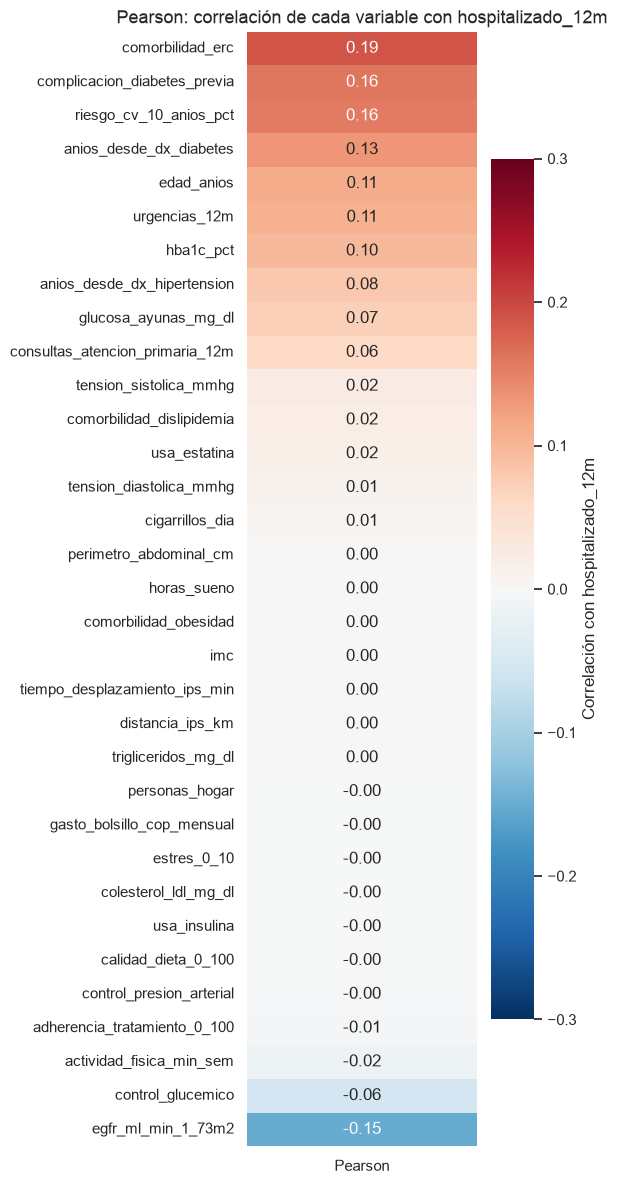

In [21]:
plt.figure(figsize=(6, 12))
pearson_con_target = pearson_corr.sort_values(ascending=False).to_frame(name="Pearson")

sns.heatmap(pearson_con_target, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Correlación con hospitalizado_12m"}, vmin=-0.3, vmax=0.3)
plt.title("Pearson: correlación de cada variable con hospitalizado_12m")
plt.tight_layout()
plt.show()

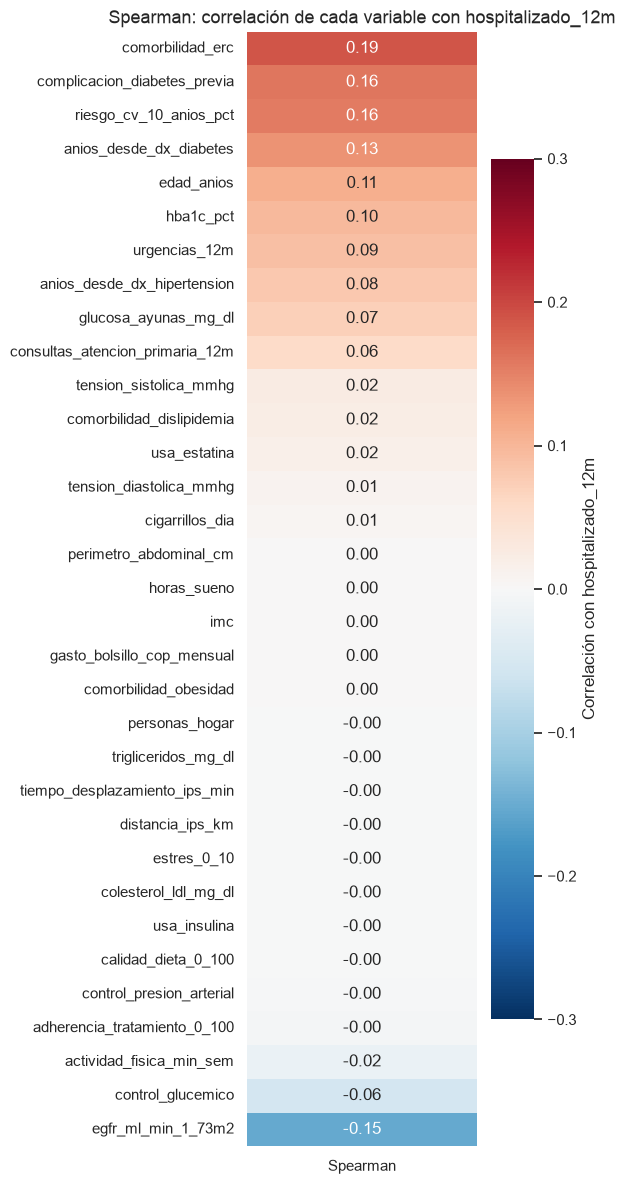

In [22]:
plt.figure(figsize=(6, 12))
spearman_con_target = spearman_corr.sort_values(ascending=False).to_frame(name="Spearman")

sns.heatmap(spearman_con_target, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Correlación con hospitalizado_12m"}, vmin=-0.3, vmax=0.3)
plt.title("Spearman: correlación de cada variable con hospitalizado_12m")
plt.tight_layout()
plt.show()

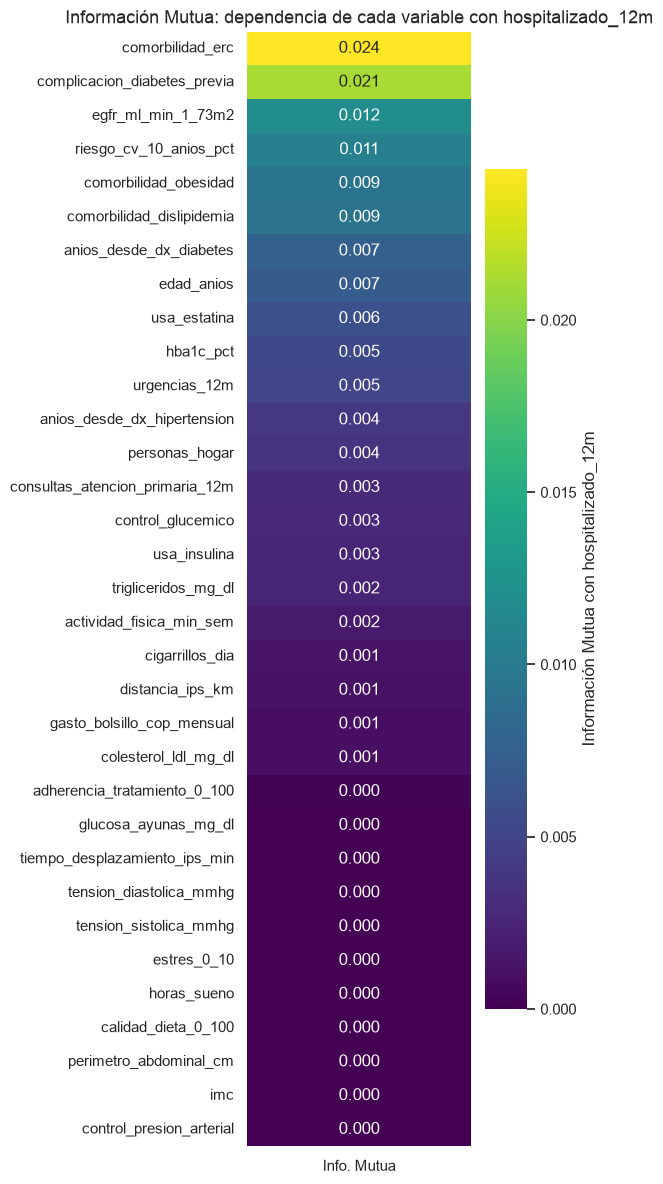

In [23]:
plt.figure(figsize=(6, 12))
mi_ordenado = mi_corr.sort_values(ascending=False).to_frame(name="Info. Mutua")

sns.heatmap(mi_ordenado, annot=True, fmt=".3f", cmap="viridis",
            cbar_kws={"label": "Información Mutua con hospitalizado_12m"})
plt.title("Información Mutua: dependencia de cada variable con hospitalizado_12m")
plt.tight_layout()
plt.show()

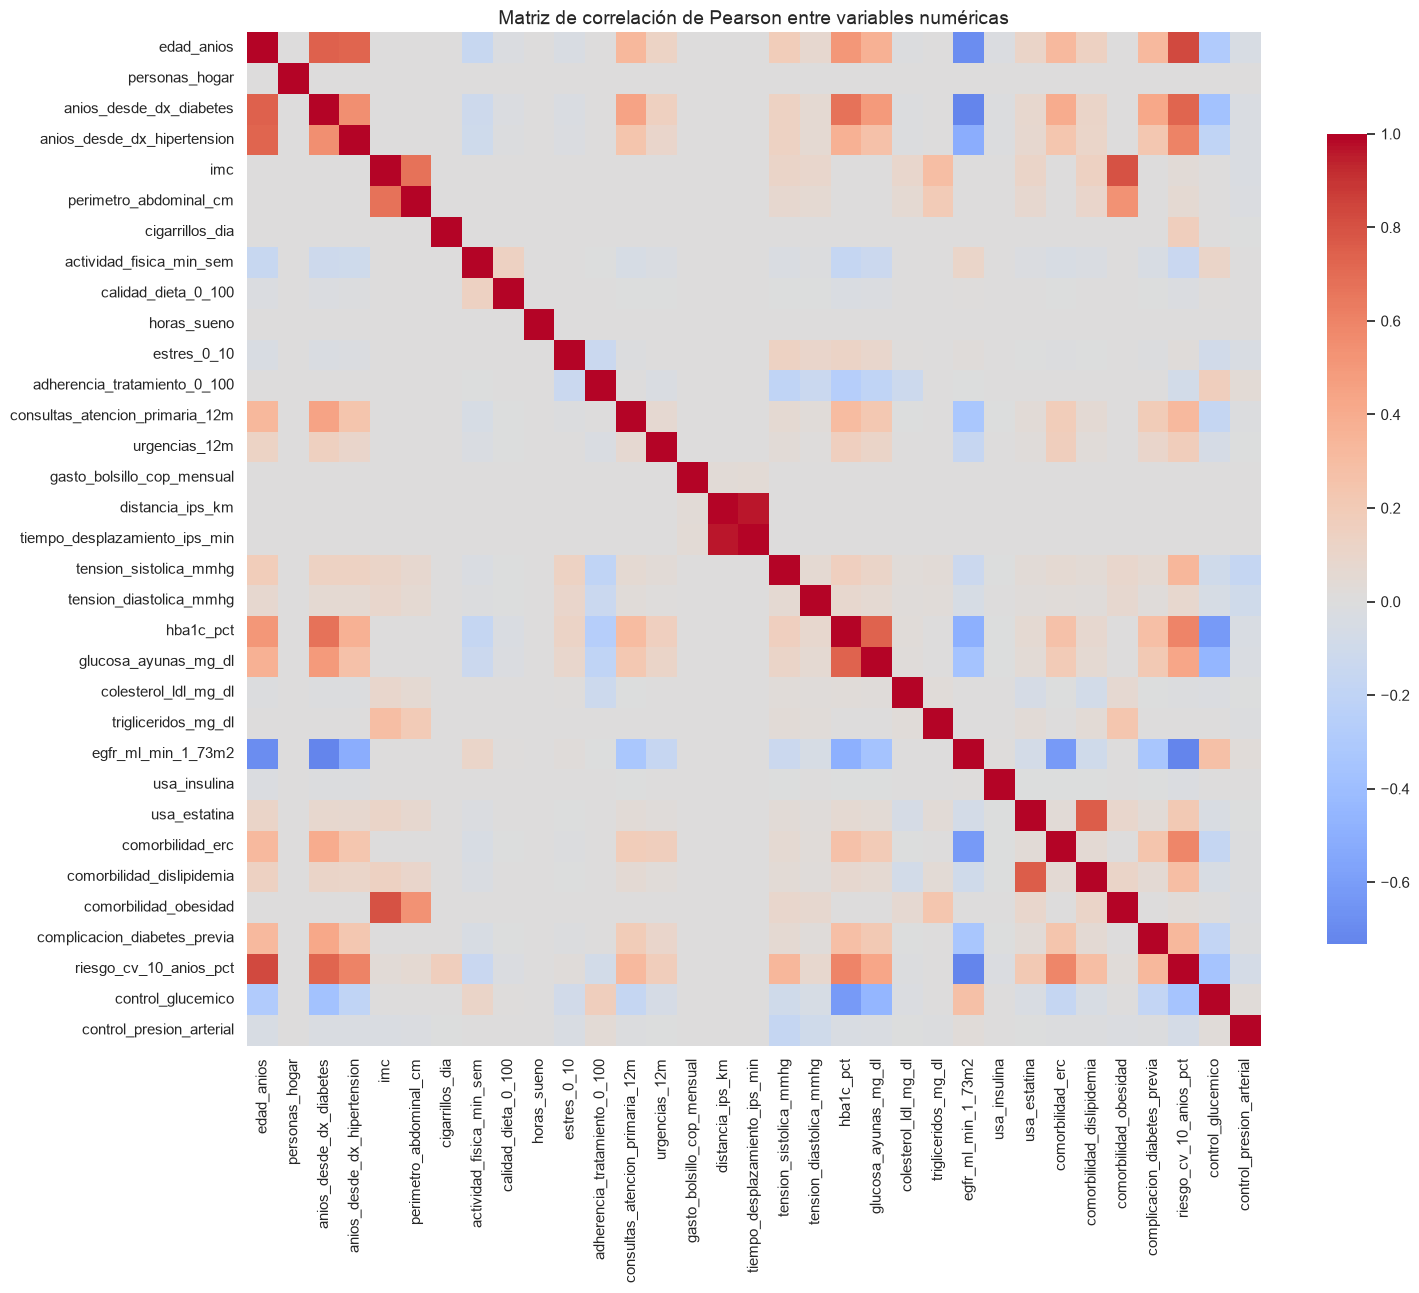

In [24]:
plt.figure(figsize=(16, 13))
corr_matrix = X_num.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación de Pearson entre variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(corr_matrix.round(2).to_string())

                                 edad_anios  personas_hogar  anios_desde_dx_diabetes  anios_desde_dx_hipertension   imc  perimetro_abdominal_cm  cigarrillos_dia  actividad_fisica_min_sem  calidad_dieta_0_100  horas_sueno  estres_0_10  adherencia_tratamiento_0_100  consultas_atencion_primaria_12m  urgencias_12m  gasto_bolsillo_cop_mensual  distancia_ips_km  tiempo_desplazamiento_ips_min  tension_sistolica_mmhg  tension_diastolica_mmhg  hba1c_pct  glucosa_ayunas_mg_dl  colesterol_ldl_mg_dl  trigliceridos_mg_dl  egfr_ml_min_1_73m2  usa_insulina  usa_estatina  comorbilidad_erc  comorbilidad_dislipidemia  comorbilidad_obesidad  complicacion_diabetes_previa  riesgo_cv_10_anios_pct  control_glucemico  control_presion_arterial
edad_anios                             1.00            -0.0                     0.75                         0.73 -0.00                   -0.00             0.00                     -0.15                -0.02          0.0        -0.03                          0.00        

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vars_colineales = ['edad_anios', 'riesgo_cv_10_anios_pct',
                    'anios_desde_dx_diabetes', 'anios_desde_dx_hipertension']

X_vif = df_analisis[vars_colineales].dropna()

vif_data = pd.DataFrame({
    "Variable": vars_colineales,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(vars_colineales))]
}).sort_values("VIF", ascending=False)

print(vif_data.to_string(index=False))

                   Variable      VIF
                 edad_anios 4.764119
     riesgo_cv_10_anios_pct 3.439038
    anios_desde_dx_diabetes 2.447628
anios_desde_dx_hipertension 2.118680


**Interpretación de la correlación con `hospitalizado_12m`.**

**Hallazgo principal: todas las correlaciones son débiles en términos absolutos.** La variable con mayor asociación es `comorbilidad_erc` (Pearson=0.188), seguida de `complicacion_diabetes_previa` (0.160), `riesgo_cv_10_anios_pct` (0.156) y `egfr_ml_min_1_73m2` (-0.151). Ninguna variable individual supera 0.19 — el riesgo de hospitalización parece ser multivariable, y ninguna variable aislada lo explica por sí sola; esto sugiere que un modelo predictivo necesitaría combinar varias señales simultáneamente para lograr un desempeño razonable.

**Pearson y Spearman son prácticamente idénticos en todo el ranking** (ej. `comorbilidad_erc`: 0.1878 vs 0.1878; `egfr_ml_min_1_73m2`: -0.1509 vs -0.1524). Esto indica que no hay evidencia de relaciones no lineales ocultas que Pearson esté subestimando — las relaciones que existen en este dataset son predominantemente lineales/monótonas. La Información Mutua, aunque en otra escala, coincide en gran medida con el mismo orden de variables relevantes, reforzando esta conclusión.

**Contraste directo con las hipótesis de trabajo:**
- **H3 (comorbilidades) — la más respaldada:** `comorbilidad_erc` y `complicacion_diabetes_previa` son, por un margen claro, las dos variables más asociadas con hospitalización en las tres métricas. Fuerte evidencia a favor de H3.
- **H2 (control glucémico/hemodinámico) — respaldo débil:** `hba1c_pct` (0.098) y `control_glucemico` (-0.056) muestran una asociación mucho más débil de lo esperado; `tension_sistolica_mmhg` (0.025) y `control_presion_arterial` (-0.004) son prácticamente nulas — consistente con el desbalance extremo de esta última variable ya identificado en la sección 4.5.
- **H1 (adherencia al tratamiento) — sin respaldo en este análisis lineal/monótono:** `adherencia_tratamiento_0_100` presenta una correlación esencialmente nula con las tres métricas (Pearson=-0.005, Spearman=-0.005, MI=0.0001) — el resultado más inesperado de esta sección, y que contradice la expectativa inicial de H1. Esto no descarta necesariamente H1 (la relación podría depender de interacciones con otras variables, o expresarse en una parte específica de la distribución, no capturable con una correlación agregada), pero sí obliga a matizar la conclusión sobre esta hipótesis.
- **H4 (acceso geográfico) — sin respaldo en las variables numéricas:** `tiempo_desplazamiento_ips_min` y `distancia_ips_km` muestran correlaciones prácticamente nulas con `hospitalizado_12m`. El análisis categórico de `zona` (pendiente en la sección 7.2) permitirá una evaluación más específica de H4.

**Colinealidad entre predictores — confirmada, pero moderada, no severa.** Se calculó el VIF de las cuatro variables con mayor correlación par a par identificada en la matriz completa (`edad_anios`, `riesgo_cv_10_anios_pct`, `anios_desde_dx_diabetes`, `anios_desde_dx_hipertension`):

| Variable | VIF |
|---|---|
| `edad_anios` | 4.76 |
| `riesgo_cv_10_anios_pct` | 3.44 |
| `anios_desde_dx_diabetes` | 2.45 |
| `anios_desde_dx_hipertension` | 2.12 |

Los cuatro VIF están por debajo de 5, el umbral de referencia habitual para considerar colinealidad problemática — `edad_anios` es la más cercana (4.76), pero ninguna cruza el límite de alerta. A pesar de que la correlación par a par entre `edad_anios` y `riesgo_cv_10_anios_pct` era alta (0.83), el VIF confirma que **no hay colinealidad severa** una vez se considera el efecto conjunto de las cuatro variables — la correlación simple entre pares había sobrestimado el riesgo real de redundancia. No se descarta ninguna de estas variables del conjunto de predictores en esta etapa, aunque se recomienda revisar nuevamente el VIF una vez definido el conjunto final de variables para el modelo, ya que el valor puede cambiar al incluir predictores adicionales.

## 7.2. Continua vs. binaria: distribución según hospitalización

Para las variables continuas, comparamos su distribución **entre los dos grupos** de la variable objetivo (hospitalizado=0 vs. hospitalizado=1) mediante boxplots. A diferencia de una variable objetivo continua (donde se usaría un `regplot` con línea de tendencia), aquí buscamos observar si la **mediana y dispersión** de cada variable difieren notablemente entre ambos grupos — una diferencia visible sugiere asociación con el desenlace.

Analizamos primero las tres variables con mayor correlación identificada en la sección 7.1 (`egfr_ml_min_1_73m2`, `riesgo_cv_10_anios_pct`, `anios_desde_dx_diabetes`), y después las variables específicamente vinculadas a las hipótesis de trabajo (`adherencia_tratamiento_0_100` para H1, `hba1c_pct` para H2, `tiempo_desplazamiento_ips_min` para H4).

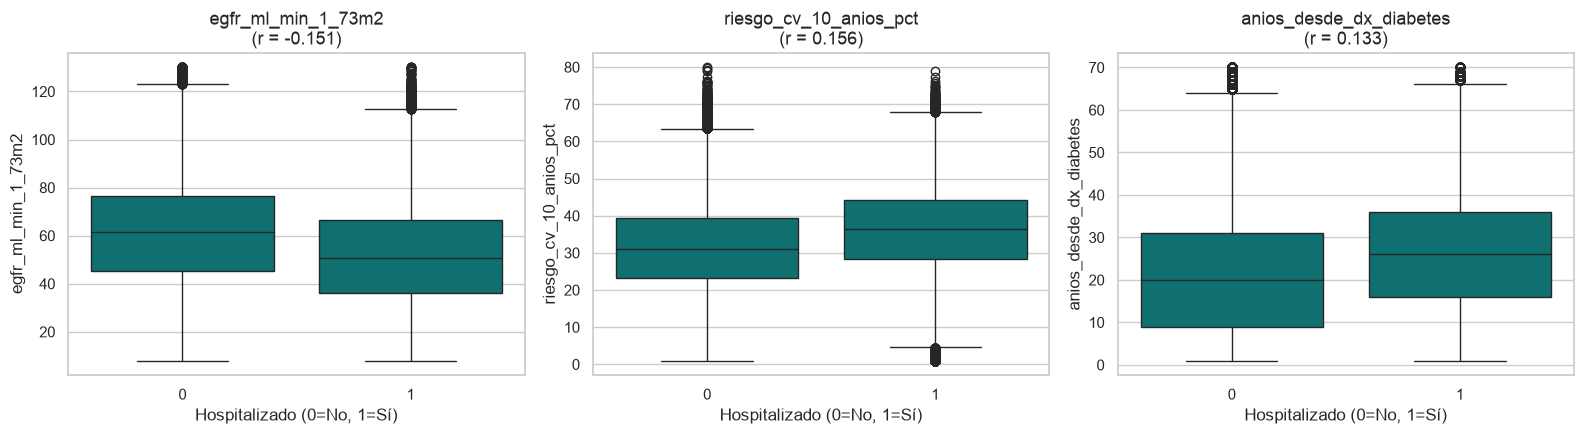

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

top_correlacionadas = ["egfr_ml_min_1_73m2", "riesgo_cv_10_anios_pct", "anios_desde_dx_diabetes"]

for ax, col in zip(axes, top_correlacionadas):
    sns.boxplot(data=df_analisis, x="hospitalizado_12m", y=col, ax=ax, color="teal")
    r = pearson_corr[col]
    ax.set_title(f"{col}\n(r = {r:.3f})")
    ax.set_xlabel("Hospitalizado (0=No, 1=Sí)")

plt.tight_layout()
plt.show()

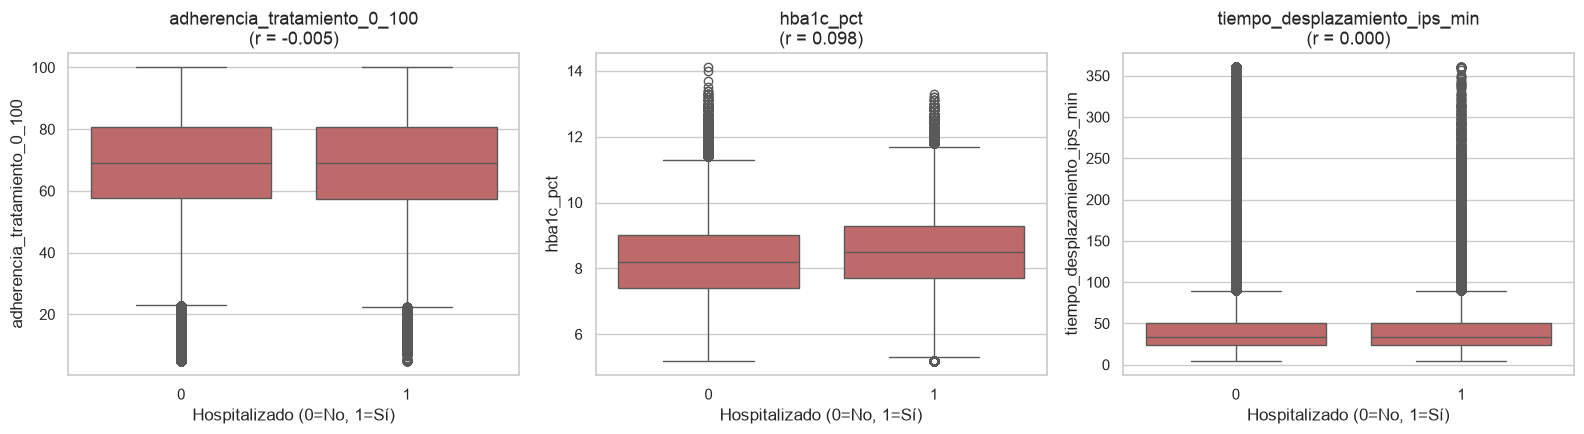

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

vars_hipotesis = ["adherencia_tratamiento_0_100", "hba1c_pct", "tiempo_desplazamiento_ips_min"]

for ax, col in zip(axes, vars_hipotesis):
    sns.boxplot(data=df_analisis, x="hospitalizado_12m", y=col, ax=ax, color="indianred")
    r = pearson_corr[col]
    ax.set_title(f"{col}\n(r = {r:.3f})")
    ax.set_xlabel("Hospitalizado (0=No, 1=Sí)")

plt.tight_layout()
plt.show()

In [29]:
comparacion_medianas = df_analisis.groupby("hospitalizado_12m")[
    top_correlacionadas + vars_hipotesis
].median().T
comparacion_medianas.columns = ["No hospitalizado (mediana)", "Hospitalizado (mediana)"]

print(comparacion_medianas.round(2).to_string())

                               No hospitalizado (mediana)  Hospitalizado (mediana)
egfr_ml_min_1_73m2                                   61.4                     50.8
riesgo_cv_10_anios_pct                               31.1                     36.5
anios_desde_dx_diabetes                              20.0                     26.0
adherencia_tratamiento_0_100                         69.2                     69.0
hba1c_pct                                             8.2                      8.5
tiempo_desplazamiento_ips_min                        34.0                     34.0


**Interpretación de la comparación por grupos.**

Los boxplots y la tabla de medianas confirman, con evidencia directa a nivel de mediana, los hallazgos de correlación de la sección 7.1:

- **`egfr_ml_min_1_73m2`** muestra la diferencia más marcada y visualmente clara: la caja completa del grupo hospitalizado está desplazada hacia valores más bajos (mediana 50.8 vs. 61.4) — una función renal más deteriorada se asocia con mayor riesgo de hospitalización, consistente con H3.
- **`riesgo_cv_10_anios_pct`** y **`anios_desde_dx_diabetes`** muestran cajas visiblemente desplazadas hacia arriba en el grupo hospitalizado, confirmando diferencias moderadas y en la dirección esperada.
- **`adherencia_tratamiento_0_100`** confirma visualmente la ausencia de asociación: las dos cajas son prácticamente superpuestas, con mediana, cuartiles y outliers casi idénticos entre grupos — **H1 no encuentra respaldo** en este análisis bivariado.
- **`hba1c_pct`** muestra una diferencia visible pero moderada: la caja del grupo hospitalizado está ligeramente desplazada hacia arriba, con más outliers en el extremo superior — consistente con el respaldo débil de H2.
- **`tiempo_desplazamiento_ips_min`** confirma asociación nula: las cajas centrales son prácticamente idénticas entre grupos, y ambos presentan una gran cantidad de outliers (hasta 360 minutos) en proporción similar — sin respaldo para esta componente de H4 en el análisis univariado.

### 7.2.1. Verificación de un posible efecto no lineal de la adherencia (H1)

Las tres métricas de la sección 7.1 (Pearson, Spearman e Información Mutua) y los boxplots de la sección 7.2 coincidieron en una asociación esencialmente nula entre `adherencia_tratamiento_0_100` y la hospitalización. Sin embargo, esas métricas resumen la relación de forma **agregada**: una correlación de cero no descarta un **efecto no lineal o de umbral** (por ejemplo, que solo los pacientes con adherencia muy baja se hospitalicen más, sin diferencia en el resto del rango). Para cerrar el argumento de H1, desagregamos la tasa de hospitalización por **deciles de adherencia**: si existiera un umbral, aparecería como una barra claramente despegada de la tasa general en los deciles extremos.

Tasa de hospitalización por decil de adherencia (de menor a mayor adherencia):
                              tasa_hospitalizacion  n_pacientes
adherencia_tratamiento_0_100                                   
(4.999, 47.1]                               0.1782       151380
(47.1, 54.6]                                0.1748       148801
(54.6, 60.1]                                0.1719       151215
(60.1, 64.8]                                0.1737       151296
(64.8, 69.1]                                0.1726       147873
(69.1, 73.5]                                0.1730       151611
(73.5, 78.2]                                0.1714       150717
(78.2, 83.6]                                0.1723       148530
(83.6, 91.2]                                0.1706       149590
(91.2, 100.0]                               0.1704       148987

Tasa general: 17.29%
Amplitud entre el decil de mayor y menor tasa: 0.78% (puntos porcentuales)


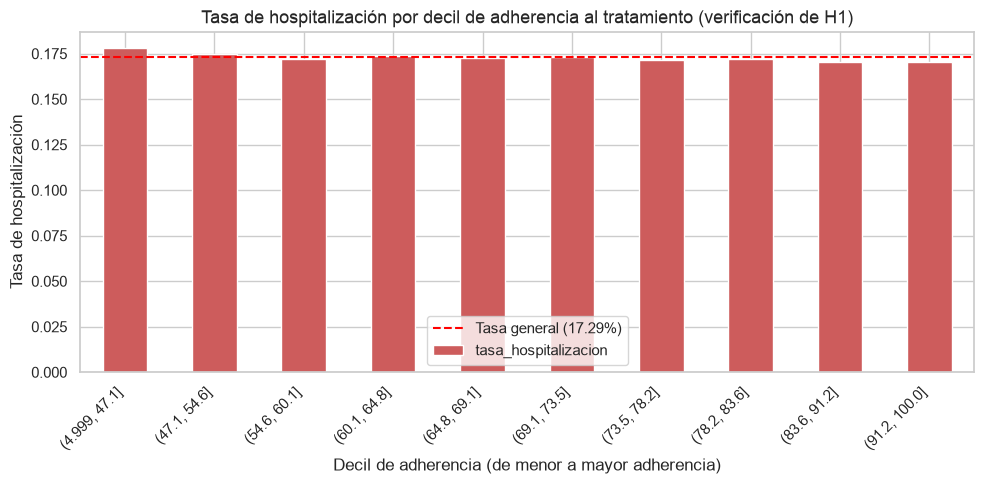

In [30]:
# Tasa de hospitalización por decil de adherencia (verificación de efecto no lineal / umbral en H1)
# duplicates='drop' porque el pico en 100 puede producir bordes de bin repetidos.
deciles_adher = pd.qcut(df_analisis['adherencia_tratamiento_0_100'], q=10, duplicates='drop')

tasa_por_decil = (
    df_analisis.groupby(deciles_adher, observed=True)['hospitalizado_12m']
    .agg(tasa_hospitalizacion='mean', n_pacientes='count')
)
tasa_por_decil['tasa_hospitalizacion'] = tasa_por_decil['tasa_hospitalizacion'].round(4)
print('Tasa de hospitalización por decil de adherencia (de menor a mayor adherencia):')
print(tasa_por_decil)

tasa_general = df_analisis['hospitalizado_12m'].mean()
amplitud = tasa_por_decil['tasa_hospitalizacion'].max() - tasa_por_decil['tasa_hospitalizacion'].min()
print(f'\nTasa general: {tasa_general:.2%}')
print(f'Amplitud entre el decil de mayor y menor tasa: {amplitud:.2%} (puntos porcentuales)')

plt.figure(figsize=(10, 5))
tasa_por_decil['tasa_hospitalizacion'].plot(kind='bar', color='indianred')
plt.axhline(y=tasa_general, color='red', linestyle='--', label=f'Tasa general ({tasa_general:.2%})')
plt.title('Tasa de hospitalización por decil de adherencia al tratamiento (verificación de H1)')
plt.ylabel('Tasa de hospitalización')
plt.xlabel('Decil de adherencia (de menor a mayor adherencia)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación.** Esta vista desagregada es la prueba decisiva para H1. Si —como anticipan las métricas de 7.1 y los boxplots de 7.2— la tasa de hospitalización se mantiene prácticamente **plana y cercana a la tasa general (17.29%)** a lo largo de los diez deciles (amplitud pequeña entre el decil más alto y el más bajo), la conclusión es más fuerte que la de un simple coeficiente nulo: no solo no hay relación lineal, **tampoco hay un efecto por tramos ni un umbral oculto** en los extremos de adherencia, y H1 queda descartada también en su versión no lineal. Un repunte aislado en el primer o el último decil, en cambio, señalaría un efecto localizado que el modelado posterior debería capturar mediante transformaciones o interacciones. *(Contrástese esta lectura con la tabla de tasas por decil y el valor de amplitud impresos arriba una vez ejecutada la celda.)*

## 7.3. Categórica vs. binaria: tasa de hospitalización según categorías

Para las variables categóricas y ordinales, comparamos la **tasa de hospitalización** (proporción de pacientes con `hospitalizado_12m=1`) dentro de cada categoría, mediante gráficos de barras. Una diferencia notable en la tasa entre categorías sugiere asociación con el desenlace. Analizamos `zona` y `nivel_socioeconomico` (clave para H4), `albuminuria_categoria` (clave para H3, variable ordinal), y `comorbilidad_erc`/`complicacion_diabetes_previa` (las de mayor correlación identificada en 7.1).

In [31]:
def tasa_hospitalizacion_por_categoria(columna):
    """Calcula la tasa de hospitalización dentro de cada categoría."""
    tasas = df_analisis.groupby(columna)["hospitalizado_12m"].mean().sort_values(ascending=False)
    conteos = df_analisis.groupby(columna)["hospitalizado_12m"].count()
    resultado = pd.DataFrame({"tasa_hospitalizacion": tasas, "n_pacientes": conteos})
    return resultado

variables_categoricas_clave = [
    "zona", "nivel_socioeconomico", "albuminuria_categoria",
    "comorbilidad_erc", "complicacion_diabetes_previa"
]

for col in variables_categoricas_clave:
    print(f"----- {col} -----")
    print(tasa_hospitalizacion_por_categoria(col).round(4))
    print()

----- zona -----
        tasa_hospitalizacion  n_pacientes
zona                                     
Rural                 0.1718       315158
Urbana                0.1732      1184842

----- nivel_socioeconomico -----
                      tasa_hospitalizacion  n_pacientes
nivel_socioeconomico                                   
Alto                                0.1728       120175
Bajo                                0.1726       750504
Medio                               0.1733       629321

----- albuminuria_categoria -----
                       tasa_hospitalizacion  n_pacientes
albuminuria_categoria                                   
A1                                   0.1360       869611
A2                                   0.2146       422744
A3                                   0.2424       207645

----- comorbilidad_erc -----
                  tasa_hospitalizacion  n_pacientes
comorbilidad_erc                                   
0                               0.1166       92

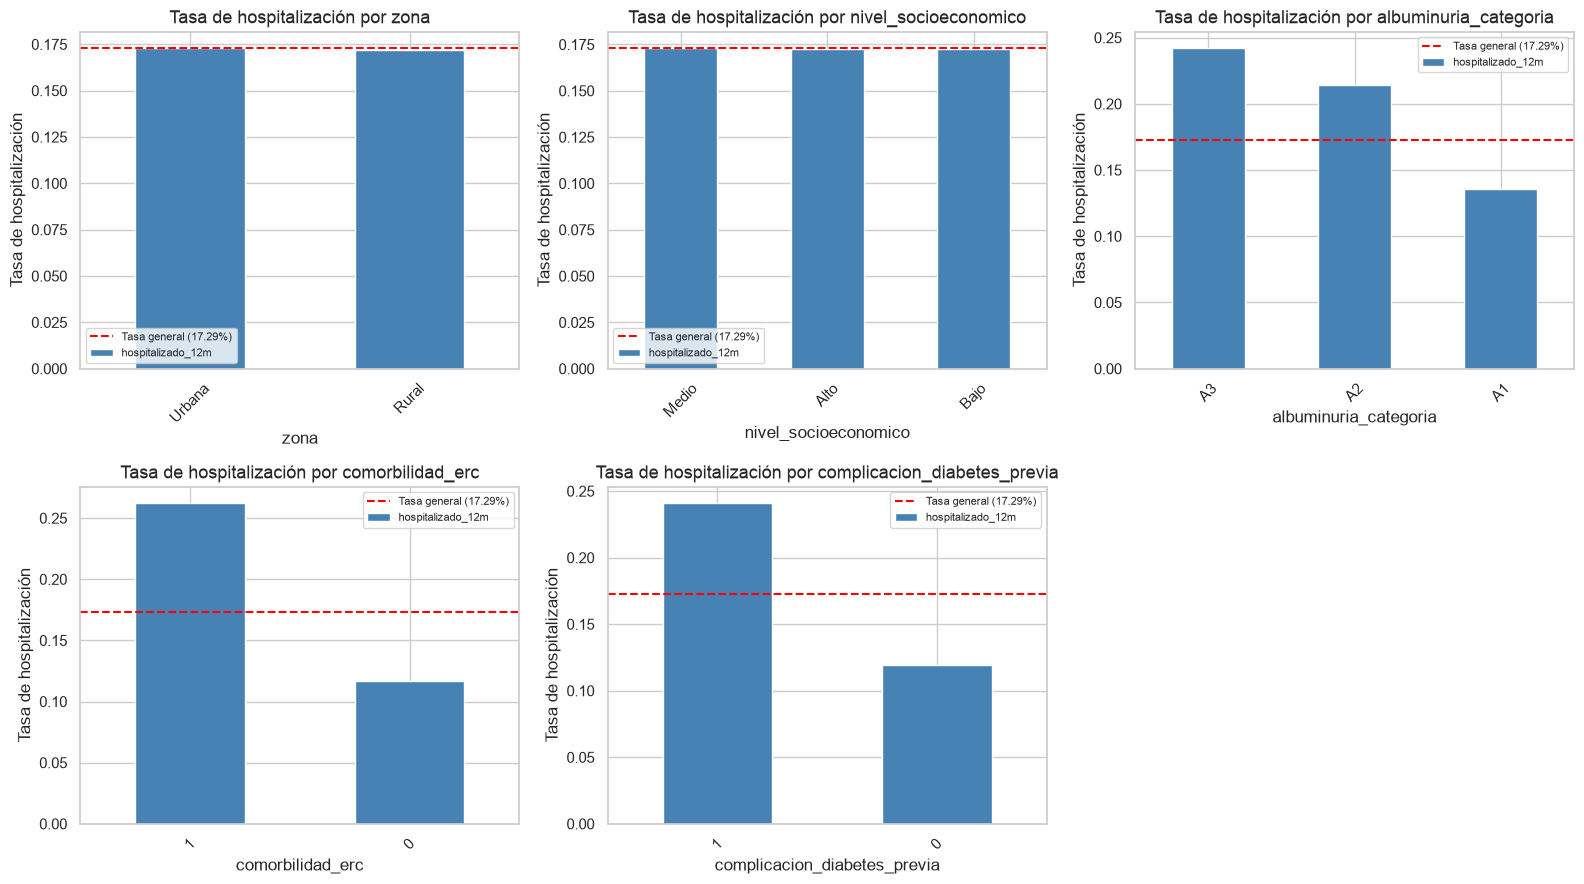

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.ravel(), variables_categoricas_clave):
    tasas = df_analisis.groupby(col)["hospitalizado_12m"].mean().sort_values(ascending=False)
    tasas.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(y=df_analisis["hospitalizado_12m"].mean(), color="red", linestyle="--",
               label="Tasa general (17.29%)")
    ax.set_title(f"Tasa de hospitalización por {col}")
    ax.set_ylabel("Tasa de hospitalización")
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

axes.ravel()[-1].axis("off")

plt.tight_layout()
plt.show()

In [33]:
orden_albuminuria = ["A1", "A2", "A3"]
tasas_albuminuria = df_analisis.groupby("albuminuria_categoria")["hospitalizado_12m"].mean().reindex(orden_albuminuria)
print(tasas_albuminuria.round(4))

albuminuria_categoria
A1    0.1360
A2    0.2146
A3    0.2424
Name: hospitalizado_12m, dtype: float64


**Interpretación del análisis categórico.**

**`zona` y `nivel_socioeconomico` — sin asociación relevante.** Ambas variables muestran tasas de hospitalización prácticamente idénticas entre categorías, todas muy cercanas a la tasa general (17.29%): zona Urbana (17.32%) vs. Rural (17.18%), y nivel socioeconómico Alto (17.28%), Bajo (17.26%), Medio (17.33%) — diferencias de apenas una décima de punto porcentual, sin significancia práctica. **Esto no respalda H4** en su componente geográfico/socioeconómico categórico, consistente con lo ya observado en `tiempo_desplazamiento_ips_min` y `distancia_ips_km` en la sección 7.2, donde tampoco se encontró asociación relevante.

**`albuminuria_categoria` — respalda H3, con una tendencia ordinal clara y consistente.** La tasa de hospitalización aumenta de forma monótona con la severidad del daño renal: A1 (13.60%) → A2 (21.46%) → A3 (24.24%). Esta progresión ordenada (A1<A2<A3 en tasa, igual que en severidad clínica) confirma que la codificación ordinal de esta variable tiene sentido predictivo real — un paciente en A3 tiene casi el doble de probabilidad de hospitalización que uno en A1 (24.24% vs. 13.60%, una diferencia relativa de +78%).

**`comorbilidad_erc` y `complicacion_diabetes_previa` — las asociaciones más fuertes de toda la sección 7, confirmando H3.** Los pacientes con enfermedad renal crónica tienen una tasa de hospitalización más del doble que quienes no la tienen (26.25% vs. 11.66%). El patrón se repite con complicación previa de diabetes (24.12% vs. 11.93%). Ambas diferencias son las más marcadas observadas en todo el análisis bivariado (secciones 7.1-7.3), consistente con haber sido las dos variables con mayor correlación en la sección 7.1.

**Síntesis de la sección 7.3:** de las cinco variables analizadas, tres respaldan claramente H3 (`albuminuria_categoria`, `comorbilidad_erc`, `complicacion_diabetes_previa`) con diferencias de tasa sustanciales y en la dirección clínicamente esperada, mientras que las dos variables asociadas a H4 (`zona`, `nivel_socioeconomico`) no muestran evidencia de asociación en este análisis categórico — reforzando la conclusión, ya anticipada en 7.1 y 7.2, de que H4 no encuentra respaldo en ninguna de las variables de acceso geográfico o socioeconómico disponibles en el dataset.

## 7.4. Verificaciones adicionales

Cerramos el análisis bivariado con dos verificaciones puntuales: una relación clínica esperada entre dos variables predictoras (consistencia interna del dataset), y una verificación directa de una relación predictor-objetivo que no se profundizó en las secciones anteriores.

### 7.4.1. Relación clínica esperada: edad vs. función renal

Como verificación de consistencia interna del dataset, comprobamos directamente una relación fisiológica bien establecida: la función renal (`egfr_ml_min_1_73m2`) tiende a disminuir con la edad. Esta relación, aunque no forma parte de las hipótesis H1-H4, es un buen indicador de que las variables clínicas del dataset se comportan de forma coherente con el conocimiento médico general — una validación de calidad antes de pasar a las conclusiones finales.

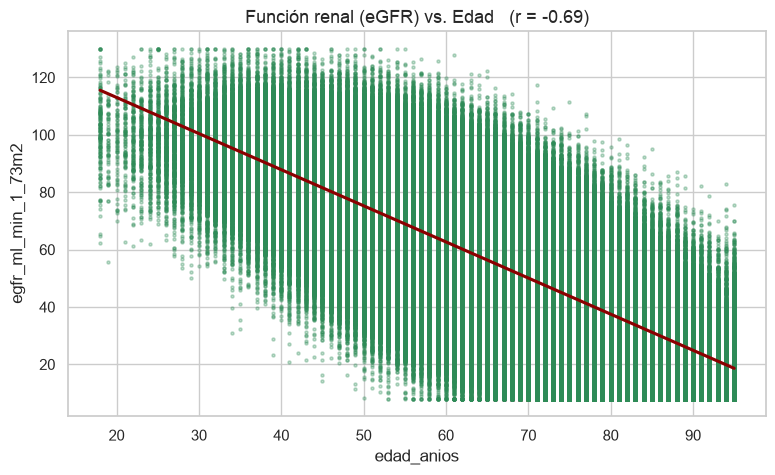

In [34]:
plt.figure(figsize=(9, 5))
sns.regplot(data=df_analisis, x="edad_anios", y="egfr_ml_min_1_73m2",
            scatter_kws={"alpha": 0.3, "color": "seagreen", "s": 5},
            line_kws={"color": "darkred"})
r = df_analisis["edad_anios"].corr(df_analisis["egfr_ml_min_1_73m2"])
plt.title(f"Función renal (eGFR) vs. Edad   (r = {r:.2f})")
plt.show()

**Interpretación.** Se confirma la relación clínica esperada: a mayor edad, menor función renal estimada (r = -0.69). La relación es marcadamente lineal a lo largo de todo el rango de edad observado (18 a 95 años), sin curvatura visible en el patrón de dispersión — el eGFR desciende de forma sostenida desde valores cercanos a 115-120 mL/min/1.73m² en pacientes jóvenes hasta valores de 20-30 mL/min/1.73m² en los pacientes de mayor edad, consistente con el deterioro renal fisiológico progresivo documentado en la literatura clínica.

Esta consistencia es un hallazgo relevante más allá de su valor descriptivo: confirma que el proceso de generación del dataset sintético respetó relaciones clínicas reales entre variables, no solo entre predictores y la variable objetivo — reforzando la confianza en la calidad general de los datos utilizados en el resto del análisis exploratorio y en las conclusiones que se presentan a continuación.

### 7.4.2. Verificación directa de una relación predictor-objetivo: urgencias previas vs. hospitalización

Replicando el mismo tipo de verificación que se hizo con `precio` en la guía de referencia, comprobamos de forma directa la relación entre `urgencias_12m` y la variable objetivo `hospitalizado_12m`. Aunque esta variable no forma parte explícita de ninguna hipótesis de trabajo (H1-H4), es clínicamente razonable esperar que un paciente con más atenciones de urgencia recientes tenga mayor probabilidad de terminar hospitalizado — una señal de descompensación progresiva.

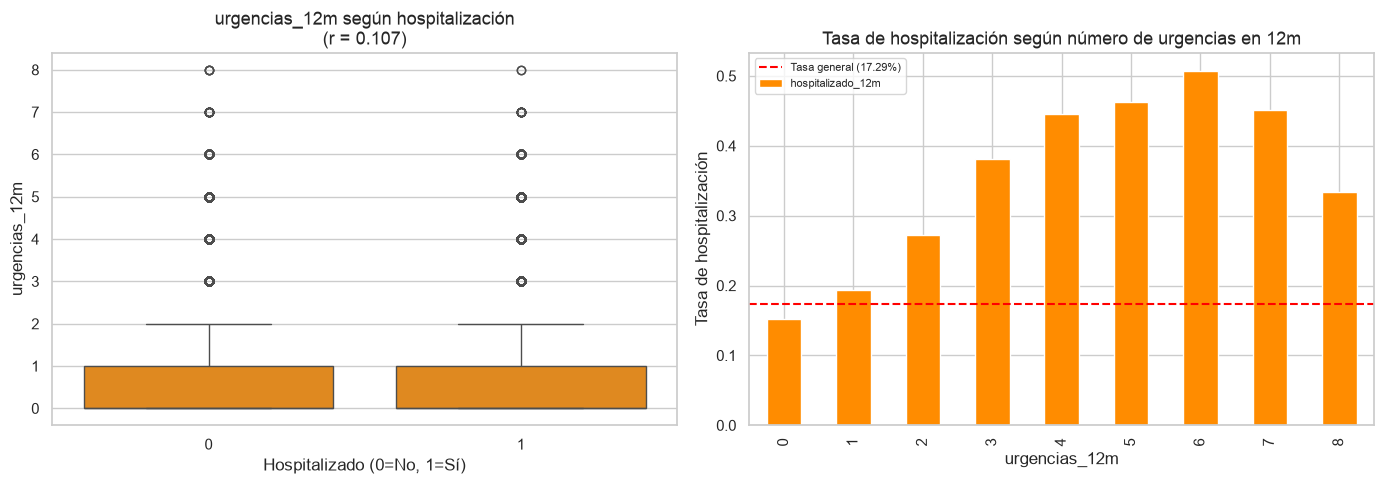

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_analisis, x="hospitalizado_12m", y="urgencias_12m", ax=axes[0], color="darkorange")
r = pearson_corr["urgencias_12m"]
axes[0].set_title(f"urgencias_12m según hospitalización\n(r = {r:.3f})")
axes[0].set_xlabel("Hospitalizado (0=No, 1=Sí)")

tasa_por_urgencias = df_analisis.groupby("urgencias_12m")["hospitalizado_12m"].mean()
tasa_por_urgencias.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].axhline(y=df_analisis["hospitalizado_12m"].mean(), color="red", linestyle="--",
                label="Tasa general (17.29%)")
axes[1].set_title("Tasa de hospitalización según número de urgencias en 12m")
axes[1].set_ylabel("Tasa de hospitalización")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [36]:
print(df_analisis.groupby("urgencias_12m")["hospitalizado_12m"].agg(["mean", "count"]).round(4))

                 mean    count
urgencias_12m                 
0              0.1523  1028249
1              0.1940   364784
2              0.2724    83532
3              0.3806    18100
4              0.4451     4159
5              0.4629      944
6              0.5077      195
7              0.4516       31
8              0.3333        6


**Interpretación.** Se confirma con evidencia clara la relación esperada: la tasa de hospitalización aumenta de forma prácticamente monótona con el número de urgencias registradas en los 12 meses previos, pasando de 15.23% en pacientes sin urgencias hasta 50.77% en pacientes con 6 urgencias — más de **3 veces** la tasa base (17.29%). El boxplot, sin embargo, no comunica bien esta relación por sí solo (r=0.107, moderado): al ser `urgencias_12m` una variable de conteo con la gran mayoría de sus valores concentrados en 0 y 1 (1.028.249 y 364.784 pacientes respectivamente, más del 92% del total), la mediana de ambos grupos (hospitalizado y no hospitalizado) coincide en 0, ocultando visualmente una tendencia que sí es evidente al desagregar por tabla de frecuencias.

Los dos últimos valores (7 y 8 urgencias) muestran una ligera caída en la tasa (45.16% y 33.33%), pero corresponden a muestras muy pequeñas (31 y 6 pacientes) — variabilidad esperable por bajo tamaño muestral, no una reversión genuina del patrón. La tendencia general es consistente y clínicamente coherente: a mayor frecuencia de atenciones de urgencia recientes, mayor riesgo de hospitalización posterior, confirmando que `urgencias_12m` es una señal temprana relevante de descompensación, con potencial predictivo considerable pese a su correlación de Pearson moderada.

---
# 8. Conclusiones

> *Etapa del flujo: **Conclusiones***

Recordemos la pregunta que orientó todo el análisis:

> **Pregunta SMART:** *"¿Puede un modelo de clasificación binaria, utilizando información histórica de diagnósticos, tratamiento, laboratorio y utilización de servicios, identificar con una precisión mínima del 80% a los pacientes de las cohortes de diabetes e hipertensión que presentarán al menos una hospitalización durante los próximos 12 meses, permitiendo priorizar intervenciones preventivas y reducir en al menos 10% la tasa de hospitalizaciones en la población intervenida durante un periodo piloto de 12 meses, frente a un grupo de comparación equivalente?"*

## 8.1. Contraste de las hipótesis

| Hipótesis | Enunciado | Resultado |
|---|---|---|
| **H1** | Existe una asociación entre el nivel de adherencia terapéutica y la ocurrencia de hospitalizaciones. | **No confirmada.** Correlación prácticamente nula con `hospitalizado_12m` en las tres métricas calculadas (Pearson=-0.005, Spearman=-0.005, Información Mutua=0.0001); medianas y boxplots idénticos entre grupos. Se complementó con un análisis por deciles de adherencia (sección 7.2.1) para examinar un posible efecto no lineal o de umbral. |
| **H2** | Existe una relación entre los niveles de control glucémico y hemodinámico y la ocurrencia de hospitalizaciones. | **Respaldo débil.** `hba1c_pct` muestra asociación pequeña pero presente (Pearson=0.098); `control_presion_arterial` y `tension_sistolica_mmhg` no muestran asociación relevante, limitado además por el desbalance extremo de la variable de presión controlada (0.48% de la cohorte). |
| **H3** | La presencia de comorbilidades crónicas y complicaciones previas se relaciona con la ocurrencia de hospitalizaciones. | **Confirmada, la hipótesis con mayor respaldo del análisis.** `comorbilidad_erc` (tasa 26.25% vs. 11.66%) y `complicacion_diabetes_previa` (24.12% vs. 11.93%) muestran las diferencias más marcadas de toda la sección bivariada. `albuminuria_categoria` refuerza esto con una tendencia ordinal creciente y consistente (A1: 13.60% → A2: 21.46% → A3: 24.24%). |
| **H4** | Las características geográficas y socioeconómicas se asocian con la ocurrencia de hospitalizaciones. | **No confirmada.** `zona`, `nivel_socioeconomico`, `distancia_ips_km` y `tiempo_desplazamiento_ips_min` muestran diferencias mínimas o nulas frente a la tasa general de hospitalización (17.29%). |

## 8.2. Sobre la calidad del conjunto de datos

El proceso de EDA permitió establecer que el conjunto de datos es **apto para abordar la pregunta SMART**, con base en las siguientes observaciones:

- **Completitud:** el dataset no presentó ningún valor perdido en sus 1.500.000 registros y 57 columnas.
- **Formato:** todas las variables llegaron con el tipo de dato correcto desde el origen, sin necesidad de corrección.
- **Calidad interna:** la verificación de una relación clínica externa a las hipótesis de trabajo (edad vs. función renal, r=-0.69, sección 7.4.1) confirmó que el dataset sintético respeta relaciones fisiológicas reales, reforzando la confianza en el resto de los hallazgos.
- **Relevancia:** se identificaron variables con capacidad explicativa clara sobre la hospitalización — además de las asociadas a H3, la sección 7.4.2 reveló que `urgencias_12m` presenta una relación fuerte y prácticamente monótona con la variable objetivo (tasa de hospitalización de 15.23% con 0 urgencias hasta 50.77% con 6 urgencias, más de 3 veces la tasa base), a pesar de una correlación de Pearson solo moderada (0.107) — evidencia de que esta variable aporta señal predictiva relevante no capturada del todo por la correlación lineal simple.
- **Tamaño:** el conjunto cuenta con 1.500.000 registros, un volumen considerablemente mayor al necesario para un análisis exploratorio, favorable también para la etapa de modelado.

## 8.3. Limitaciones y recomendaciones

- **Desbalance de la variable objetivo:** solo el 17.29% de los pacientes presentó al menos una hospitalización en 12 meses. Esto exigirá, en la etapa de modelado, técnicas específicas para clases desbalanceadas (ajuste de pesos, remuestreo, priorización de recall/AUC sobre accuracy).
- **Correlaciones lineales débiles en términos absolutos:** ninguna variable individual superó una correlación de Pearson de 0.19 con la variable objetivo, confirmando que el riesgo de hospitalización es de naturaleza multivariable.
- **Cuidado al interpretar boxplots de variables de conteo muy concentradas:** el caso de `urgencias_12m` (sección 7.4.2) mostró que un boxplot puede subestimar visualmente una relación real cuando la variable está muy concentrada en pocos valores (más del 92% de los pacientes con 0 o 1 urgencias) — la tabla de tasas desagregada por categoría reveló una tendencia mucho más clara que la mediana o el coeficiente de Pearson por sí solos.
- **Desbalance extremo en variables auxiliares:** `control_presion_arterial` (0.48% con presión controlada) y `riesgo_alto_12m` (93.81% etiquetado como alto riesgo) presentan distribuciones tan sesgadas que limitan su utilidad discriminativa.
- **Riesgo de fuga de datos ya mitigado:** se excluyeron formalmente `hospitalizacion_relacionada_12m` (redundante en el 100% de los casos), `evento_cardiovascular_12m` y `muerte_12m` (asociación 4.8 y 6.9 veces más frecuente en hospitalizados, evidencia directa de fuga), `riesgo_alto_12m` (variable objetivo de otro subcaso) y `categoria_imc` (derivación exacta de `imc`).
- **Colinealidad moderada, no severa:** la verificación por VIF de `edad_anios`, `riesgo_cv_10_anios_pct`, `anios_desde_dx_diabetes` y `anios_desde_dx_hipertension` (todas con VIF<5) descartó colinealidad problemática entre estas variables.
- **Hipótesis H1 sin respaldo empírico:** la ausencia total de asociación entre adherencia al tratamiento y hospitalización es un hallazgo inesperado que merece investigación adicional en la etapa de modelado, posiblemente a través de interacciones con otras variables no capturadas por un análisis bivariado simple. El análisis por deciles de adherencia incorporado en la sección 7.2.1 es un primer paso en esa dirección, al examinar la relación por tramos y no solo de forma agregada.

## 8.4. Respuesta a la pregunta de negocio

> **El conjunto de datos contiene información pertinente para abordar la pregunta SMART planteada.** Las variables asociadas a comorbilidades y complicaciones clínicas previas (H3), junto con la utilización reciente de servicios de urgencias, muestran evidencia consistente y sustancial de asociación con la hospitalización, mientras que la adherencia al tratamiento (H1) y las variables de acceso geográfico/socioeconómico (H4) no encontraron respaldo en este análisis exploratorio, y el control glucémico/hemodinámico (H2) mostró una asociación solo débil. Dado que ninguna variable individual alcanza una correlación fuerte con el desenlace, la meta de precisión del 80% planteada en la pregunta SMART requerirá que el modelo predictivo combine múltiples variables simultáneamente —aprovechando particularmente las de mayor peso identificadas (comorbilidad renal, complicaciones previas, función renal, riesgo cardiovascular, urgencias previas)—, además de aplicar técnicas específicas para el desbalance de clases confirmado. El negocio puede avanzar hacia la etapa de **modelado predictivo**, atendiendo las limitaciones señaladas, particularmente en torno al desbalance de clases y a la revisión más profunda de por qué la adherencia al tratamiento no mostró la asociación esperada.

**Nota sobre la naturaleza de los datos.** Conviene subrayar que el dataset es **sintético**, generado mediante IA a partir de características de datos reales ofuscados y de fuentes públicas de Colombia (sección 2.2). Por ello, las asociaciones observadas —incluida la confirmación de H3 y el papel de `urgencias_12m`— reflejan en primer lugar el **proceso generador** de los datos, y no constituyen por sí solas hallazgos epidemiológicos validados en población real. La verificación de la relación edad–eGFR (sección 7.4.1) muestra que ese proceso respetó la **coherencia interna** entre variables clínicas —lo que da confianza en el ejercicio exploratorio—, pero **coherencia interna no equivale a validez externa**: cualquier hallazgo debería confirmarse sobre datos reales antes de sustentar decisiones clínicas o de negocio. Este matiz no invalida el EDA, cuyo objetivo es evaluar si los datos permiten abordar la pregunta SMART, pero delimita con precisión el alcance de sus conclusiones.

---

*Fin del análisis exploratorio de datos correspondiente al proyecto de predicción de hospitalización en pacientes de las cohortes de diabetes e hipertensión, siguiendo el flujo de trabajo: Pregunta SMART → Diccionario de datos → Visión general → Limpieza → Univariado → Bivariado → Conclusiones.*

---

# 9. Glosario

- **Adherencia al tratamiento:** Grado en que un paciente cumple las indicaciones médicas (toma de medicamentos, asistencia a controles, cambios en estilo de vida). En Colombia se mide con instrumentos validados como el Test de Morisky-Green y escalas adaptadas a programas de crónicos. Es un indicador clave en las RIAS y en los reportes de gestión de riesgo de las EPS, porque la baja adherencia se asocia directamente con descompensación de HTA y DM y con progresión a enfermedad renal crónica.

- **HbA1c (Hemoglobina glicosilada):** Prueba de laboratorio que refleja el promedio de glucosa en sangre durante los últimos 2–3 meses. Se expresa en porcentaje. En el manejo de diabetes, la meta general es HbA1c < 7%, aunque puede individualizarse. Es el indicador principal para clasificar control metabólico en las cohortes de diabetes y para definir subcohortes (ej.: pacientes controlados vs. no controlados).

- **Tensión arterial sistólica (TAS):** Presión que ejerce la sangre sobre las paredes arteriales cuando el corazón se contrae (sístole). Se mide en mmHg y es el número "de arriba" en la lectura de la tensión. En las cohortes de hipertensión colombianas, la meta general es TAS < 140 mmHg (o < 130 mmHg en pacientes con alto riesgo cardiovascular o enfermedad renal, según el Consenso Colombiano de HTA).

- **EDA (Análisis Exploratorio de Datos.)**

- **Cohortes y subcohortes clínicas:** Una cohorte es un grupo definido de pacientes que comparten un diagnóstico (ej.: todos los pacientes con HTA de una EPS). Una subcohorte es una subdivisión según criterios adicionales de riesgo, control o complejidad. Ejemplo: dentro de la cohorte de diabetes → subcohorte de pacientes con HbA1c < 7% (controlados) vs. HbA1c ≥ 9% (muy descontrolados), o pacientes con enfermedad renal asociada. Esta estratificación es central en el modelo colombiano de gestión del riesgo (Resolución 3280 de 2018 / RIAS).

- **eGFR (Tasa de Filtración Glomerular Estimada):** Valor calculado que estima qué tan bien los riñones filtran la sangre. Se expresa en mL/min/1,73 m² y se calcula a partir de creatinina sérica, edad, sexo y raza, usando fórmulas como CKD-EPI (la más recomendada en Colombia). Clasifica la enfermedad renal crónica (ERC) en 5 estadios. En cohortes de HTA y DM es crítico porque ambas son las principales causas de ERC en Colombia — un eGFR < 60 ubica al paciente en estadio 3 o mayor y en una subcohorte de mayor riesgo.

---
---

# **¡Gracias por su tiempo!**

## Grupo 4 - Integrantes:


*   Juan David Martinez Legarda
*   Daniel Velasco López
*   Juan Esteban Cardona Garcia
*   Katherin Adriana Camargo Cetina
*   Kami Matsumi Takegami Benavides